# Transform Data

Retail data from: https://archive.ics.uci.edu/dataset/502/online+retail+ii

Read data from excel and processed total_retail to pd DataFrame.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
xl_file = pd.ExcelFile('online_retail_II.xlsx')

dfs = {sheet_name: xl_file.parse(sheet_name) 
          for sheet_name in xl_file.sheet_names}

print(dfs.keys())
dfs['Year 2010-2011'].head()

dict_keys(['Year 2009-2010', 'Year 2010-2011'])


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#### **Drop Overlapping rows**

Two sheets overlap. Between Invoice [536365, 538171], or between time [01/12/2010 08:26, 09/12/2010 20:01]. Total of 22524 entries. 

In [3]:
dfs['Year 2009-2010']['Invoice'] = dfs['Year 2009-2010']['Invoice'].astype(str)
first_repeat_ind = dfs['Year 2009-2010'][dfs['Year 2009-2010']['Invoice'] == '536365'].index[0]

# Drop all rows after the first repeat of invoice 536365 in the 2009-2010 dataset
dfs['Year 2009-2010'] = dfs['Year 2009-2010'].iloc[:first_repeat_ind]

In [4]:
# Combine and cast types of the two datasets
total_retail = pd.concat([dfs['Year 2009-2010'], dfs['Year 2010-2011']], ignore_index=True)
total_retail[['Customer ID', 'Country']] = total_retail[['Customer ID', 'Country']].astype(str)
total_retail['InvoiceDate'] = pd.to_datetime(total_retail['InvoiceDate'])
total_retail[['Invoice', 'StockCode', 'Description']] = total_retail[['Invoice', 'StockCode', 'Description']].astype(str)
total_retail.columns = [col.replace(' ', '') for col in total_retail.columns]

#### **Need to clear duplicate rows**

In [5]:
print(total_retail[total_retail.duplicated()].groupby(['Invoice', 'StockCode', 'Description']).size().reset_index(name='Count').sort_values('Count', ascending=False))

print(f"Total retail data shape: {total_retail.shape}")
print(f"Total duplicate rows: {total_retail.duplicated().sum()}")
total_retail = total_retail.drop_duplicates()
print(f"Total retail data shape after dropping duplicates: {total_retail.shape}")

       Invoice StockCode                          Description  Count
7681    555524     22698       PINK REGENCY TEACUP AND SAUCER     19
7680    555524     22697      GREEN REGENCY TEACUP AND SAUCER     11
9267    572861     22775  PURPLE DRAWERKNOB ACRYLIC EDWARDIAN      7
1451    502660     17021               NAMASTE SWAGAT INCENSE      6
4036    525065     20894  HANGING BAUBLE T-LIGHT HOLDER LARGE      5
...        ...       ...                                  ...    ...
10942  C547725     84929   ASSTD FRUIT+FLOWERS FRIDGE MAGNETS      1
10943  C548469     22624                 IVORY KITCHEN SCALES      1
10944  C550165     22962                JAM JAR WITH PINK LID      1
10945  C555723     22171     3 HOOK PHOTO SHELF ANTIQUE WHITE      1
0       489517     21491      SET OF THREE VINTAGE GIFT WRAPS      1

[10963 rows x 4 columns]
Total retail data shape: (1044848, 8)
Total duplicate rows: 11812
Total retail data shape after dropping duplicates: (1033036, 8)


In [6]:
print(f"Unique values - Invoice: {total_retail['Invoice'].nunique()}, StockCode: {total_retail['StockCode'].nunique()}, CustomerID: {total_retail['CustomerID'].nunique()}, Country: {total_retail['Country'].nunique()}")

Unique values - Invoice: 53628, StockCode: 5305, CustomerID: 5943, Country: 43


#### **Drop Bad Rows???**

Most rows with price = 0 contains random input noise. These are manual entries that are labeled by the operator to indicate some kind of adjustment or alignment between records and actual sales. A huge majority of these are items with nan Description, indicating they might just be small adjustments, they have negative quantity, and could just be cleaned up inventory. Other price = 0 entries are labeled as missing, destroyed, test product, or just gifts (these have actual product descriptions, positive quantity, but 0 price). There are only a handful of rows with price < 0, they are all labeled "adjust bad debt", which is an regulatory and administrative decision, and should not be reflected in the market prediction model.

These account for less than 0.6% of total entries

In [7]:
# Drop all rows with price <= 0
total_retail = total_retail[total_retail['Price'] > 0]
print(total_retail.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1027017 entries, 0 to 1044847
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1027017 non-null  object        
 1   StockCode    1027017 non-null  object        
 2   Description  1027017 non-null  object        
 3   Quantity     1027017 non-null  int64         
 4   InvoiceDate  1027017 non-null  datetime64[ns]
 5   Price        1027017 non-null  float64       
 6   CustomerID   1027017 non-null  object        
 7   Country      1027017 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 70.5+ MB
None


#### **Missingness**

Seems like we handled missingness during our cleaning process. We only combined, renamed, dropped overlap, and dropped bad rows (based on price). 

In [8]:
print('Percentage missing in original datasets:')
print(pd.concat([dfs['Year 2009-2010'], dfs['Year 2010-2011']], ignore_index=True).isna().sum()/len(pd.concat([dfs['Year 2009-2010'], dfs['Year 2010-2011']], ignore_index=True)))

print('Percentage missing in cleaned dataset:')
print(total_retail.isna().sum()/len(total_retail))

Percentage missing in original datasets:
Invoice        0.000000
StockCode      0.000000
Description    0.004092
Quantity       0.000000
InvoiceDate    0.000000
Price          0.000000
Customer ID    0.225188
Country        0.000000
dtype: float64
Percentage missing in cleaned dataset:
Invoice        0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
Price          0.0
CustomerID     0.0
Country        0.0
dtype: float64


#### **By-product Adjustments**

In [9]:
all_products = total_retail.groupby('StockCode')['Description'].agg(['first', 'count']).sort_values('count', ascending=False).reset_index()

### Found items with questionable StockCodes, some are likely non-product entries
# alphabetic = r'[a-zA-Z]'
# print(all_products[all_products['StockCode'].str.match(alphabetic)]['first'].unique())

non_product_entries = [
 'POSTAGE', 'DOTCOM POSTAGE', 'Manual', 'CARRIAGE', 'Discount', 
 'SAMPLES', ' Bank Charges', 'AMAZON FEE', 'ebay', 'nan',
 'CRUK Commission', 'This is a test product.', 'Adjust bad debt',
 'Dotcomgiftshop Gift Voucher £10.00', 
 'Dotcomgiftshop Gift Voucher £20.00',
 'Dotcomgiftshop Gift Voucher £30.00', 
 'Dotcomgiftshop Gift Voucher £40.00',
 'Dotcomgiftshop Gift Voucher £50.00', 
 'Dotcomgiftshop Gift Voucher £60.00', 
 'Dotcomgiftshop Gift Voucher £70.00', 
 'Dotcomgiftshop Gift Voucher £80.00', 
 'Adjustment by john on 26/01/2010 16',
 'Adjustment by Peter on Jun 25 2010 '
]

all_products = all_products[~all_products['first'].isin(non_product_entries)]
total_retail = total_retail[total_retail['StockCode'].isin(all_products['StockCode'])]
# Remaining are all valid product entries with non-numeric StockCodes
print(all_products[all_products['StockCode'].str.match(r'[a-zA-Z]')]['first'].unique())



['MISO PRETTY  GUM' 'GIRLS PARTY BAG' 'BOYS PARTY BAG'
 'PADS TO MATCH ALL CUSHIONS' 'SUNJAR LED NIGHT NIGHT LIGHT'
 'BOXED GLASS ASHTRAY' 'OOH LA LA DOGS COLLAR'
 'HAYNES CAMPER SHOULDER BAG' 'CAT CAMOUFLAGUE COLLAR'
 'CAMOUFLAGE DOG COLLAR' 'NAVY CUDDLES DOG HOODIE' 'DOGS NIGHT COLLAR'
 "KID'S CHALKBOARD/EASEL" 'CAMOUFLAGUE DOG LEAD' 'KEY-RING CORKSCREW'
 'ROAD-RAGE CAR FRESHENER' 'HANDZ-OFF CAR FRESHENER'
 'HAYNES MINI-COOPER PLAYING CARDS']


In [ ]:
all_products.to_csv('all_products_cleaned.csv', index=False)
all_products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4910 entries, 0 to 4931
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   StockCode  4910 non-null   object
 1   first      4910 non-null   object
 2   count      4910 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 153.4+ KB


# Train - test split

In [11]:
# Add useful columns for analysis
total_retail['Week'] = total_retail["InvoiceDate"].dt.to_period("W")
total_retail['Sales'] = total_retail['Quantity'] * total_retail['Price']

total_weeks = total_retail['Week'].unique()
# Impute any missing weeks
all_weeks = pd.period_range(start=total_weeks.min(), end=total_weeks.max(), freq='W')
print(f"Total weeks in dataset: {len(all_weeks)} (from {all_weeks.min()} to {all_weeks.max()})")

# Training horizon of 12 weeks
training_weeks = all_weeks[:-12]
test_weeks = all_weeks[-12:]
print(f"Training weeks: {len(training_weeks)}, Test weeks: {len(test_weeks)}")

# ── Fix 1: Rebuild all_weeks to cover train + test ────────────────────────────
all_weeks = pd.period_range(
    start = training_weeks.min(),
    end   = test_weeks.max(),      # explicitly extend to end of test period
    freq  = "W"
)
print(f"Rebuilt all_weeks: {all_weeks.min()} → {all_weeks.max()} ({len(all_weeks)} weeks)")
print(f"  Should end at: {test_weeks.max()}")

retail_train = total_retail[total_retail['Week'].isin(training_weeks)]
retail_test = total_retail[total_retail['Week'].isin(test_weeks)]
print(f"Training set shape: {retail_train.shape}, Test set shape: {retail_test.shape}")

# Train used for clustering and modelling, test set held out for future forecasting evaluation
retail_train.reset_index(drop=True, inplace=True)
retail_test.reset_index(drop=True, inplace=True)

Total weeks in dataset: 106 (from 2009-11-30/2009-12-06 to 2011-12-05/2011-12-11)
Training weeks: 94, Test weeks: 12
Rebuilt all_weeks: 2009-11-30/2009-12-06 → 2011-12-05/2011-12-11 (106 weeks)
  Should end at: 2011-12-05/2011-12-11
Training set shape: (829992, 10), Test set shape: (191280, 10)


# Clustering Features

In [ ]:
from scipy.stats import linregress
from sklearn.preprocessing import RobustScaler

# ── 0. Load & clean ───────────────────────────────────────────────────────────
retail_mod = retail_train.copy()

# Separate cancellations (InvoiceNo starting with 'C')
retail_mod["is_cancelled"] = retail_mod["Invoice"].astype(str).str.startswith("C")
cancellations = retail_mod[retail_mod["is_cancelled"]].copy()
sales = retail_mod[~retail_mod["is_cancelled"]].copy()

# Remove non-product rows (postage, manual charges, etc.)
# sales = sales[sales["Price"] > 0] # Already done in cleaning step
# sales = sales[sales["Quantity"] > 0] # All negative quantities are cancellations, already separated
# sales = sales[sales["StockCode"].astype(str).str.match(r"^\d{5}")] # valid products already filtered

# Week label for each transaction (used for weekly aggregations)
sales["week"] = sales["InvoiceDate"].dt.to_period("W")
sales["month"] = sales["InvoiceDate"].dt.month
sales["quarter"] = sales["InvoiceDate"].dt.quarter
sales["year"] = sales["InvoiceDate"].dt.year

# Full week range in the TRAINING data only (to count zero-sales weeks for clustering features)
# Note: we use all_weeks_train here to avoid overwriting all_weeks which covers train + test
all_weeks_train = pd.period_range(
    start=sales["InvoiceDate"].min().to_period("W"),
    end=sales["InvoiceDate"].max().to_period("W"),
    freq="W"
)
total_weeks = len(all_weeks_train)


# ── 1. Weekly sales per product ───────────────────────────────────────────────

weekly = (
    sales.groupby(["StockCode", "week"])["Sales"]
    .sum()
    .reset_index()
    .rename(columns={"Sales": "weekly_sales"})
)

# Pivot so every product has a row for every week (fill missing with 0)
weekly_pivot = (
    weekly.pivot(index="StockCode", columns="week", values="weekly_sales")
    .reindex(columns=all_weeks_train)
    .fillna(0)
)


# ── 2. Helper: seasonal concentration (Herfindahl index) ─────────────────────
# HHI = sum of squared monthly share. Range 0–1. Higher = more concentrated.

def herfindahl(monthly_totals):
    total = monthly_totals.sum()
    if total == 0:
        return np.nan
    shares = monthly_totals / total
    return (shares ** 2).sum()


# ── 3. Build feature table ────────────────────────────────────────────────────

features = []

for stock_code, group in sales.groupby("StockCode"):

    # --- Demand level ---
    weekly_sales = weekly_pivot.loc[stock_code] if stock_code in weekly_pivot.index else pd.Series(dtype=float)
    mean_weekly_sales    = weekly_sales.mean()
    median_weekly_sales  = weekly_sales.median()
    total_sales          = weekly_sales.sum()
    mean_txn_size      = group["Sales"].mean()

    # --- Volatility ---
    std_weekly_sales     = weekly_sales.std()
    cv                 = std_weekly_sales / mean_weekly_sales if mean_weekly_sales > 0 else np.nan
    spike_ratio        = weekly_sales.max() / mean_weekly_sales if mean_weekly_sales > 0 else np.nan

    # --- Intermittency ---
    zero_weeks         = (weekly_sales == 0).sum()
    pct_zero_weeks     = zero_weeks / total_weeks

    # Average inter-demand interval (days between consecutive transactions)
    txn_dates          = group["InvoiceDate"].sort_values()
    if len(txn_dates) > 1:
        gaps           = txn_dates.diff().dt.days.dropna()
        avg_idi        = gaps.mean()
    else:
        avg_idi        = np.nan

    # Longest streak of zero-sales weeks
    in_streak, max_streak, cur_streak = False, 0, 0
    for v in weekly_sales:
        if v == 0:
            cur_streak += 1
            max_streak = max(max_streak, cur_streak)
        else:
            cur_streak = 0
    longest_zero_streak = max_streak

    # --- Seasonality & timing ---
    monthly_sales        = group.groupby("month")["Sales"].sum().reindex(range(1, 13), fill_value=0)
    q4_pct             = monthly_sales[[10, 11, 12]].sum() / total_sales if total_sales > 0 else np.nan
    q1_pct             = monthly_sales[[1, 2, 3]].sum()   / total_sales if total_sales > 0 else np.nan
    peak_month         = int(monthly_sales.idxmax())
    seasonal_conc      = herfindahl(monthly_sales)

    # --- Trend ---
    weekly_values      = weekly_sales.values
    if len(weekly_values) > 1 and weekly_values.sum() > 0:
        x              = np.arange(len(weekly_values))
        slope, *_      = linregress(x, weekly_values)
        trend_slope    = slope
    else:
        trend_slope    = np.nan

    # Sales in last 3 months vs first 3 months
    date_min           = group["InvoiceDate"].min()
    date_max           = group["InvoiceDate"].max()
    cutoff_early       = date_min + pd.DateOffset(months=3)
    cutoff_late        = date_max - pd.DateOffset(months=3)
    early_sales        = group[group["InvoiceDate"] < cutoff_early]["Sales"].sum()
    late_sales         = group[group["InvoiceDate"] > cutoff_late]["Sales"].sum()
    trend_log_diff     = np.log1p(late_sales) - np.log1p(early_sales)

    # --- Price ---
    mean_price         = group["Price"].mean()
    std_price          = group["Price"].std()

    # --- Customer base ---
    n_unique_customers = group["CustomerID"].nunique()
    total_customers    = group["CustomerID"].count()
    repeat_customers   = total_customers - n_unique_customers
    pct_repeat         = repeat_customers / total_customers if total_customers > 0 else np.nan
    n_countries        = group["Country"].nunique()
    top_country_pct    = group["Country"].value_counts(normalize=True).iloc[0] if len(group) > 0 else np.nan

    # --- Cancellation rate ---
    cancelled_sales      = cancellations[cancellations["StockCode"] == stock_code]["Sales"].abs().sum()
    cancel_rate        = cancelled_sales / (total_sales + cancelled_sales) if (total_sales + cancelled_sales) > 0 else 0.0

    features.append({
        "StockCode":           stock_code,
        # Demand level
        "mean_weekly_sales":     mean_weekly_sales,
        "median_weekly_sales":   median_weekly_sales,
        "total_sales":           total_sales,
        "mean_txn_size":       mean_txn_size,
        # Volatility
        "std_weekly_sales":      std_weekly_sales,
        "cv":                  cv,
        "spike_ratio":         spike_ratio,
        # Intermittency
        "pct_zero_weeks":      pct_zero_weeks,
        "avg_idi_days":        avg_idi,
        "longest_zero_streak": longest_zero_streak,
        # Seasonality
        "q4_pct":              q4_pct,
        "q1_pct":              q1_pct,
        "peak_month":          peak_month,
        "seasonal_conc":       seasonal_conc,
        # Trend
        "trend_slope":         trend_slope,
        "trend_log_diff":      trend_log_diff,
        # Price
        "mean_price":          mean_price,
        "std_price":           std_price,
        # Customer base
        "n_unique_customers":  n_unique_customers,
        "pct_repeat_customers":pct_repeat,
        "n_countries":         n_countries,
        "top_country_pct":     top_country_pct,
        # Returns
        "cancel_rate":         cancel_rate,
    })

feat_df = pd.DataFrame(features).set_index("StockCode")

print(f"Feature matrix shape: {feat_df.shape}")
print(feat_df.head())

# Log-transform skewed features
feat_df["log_mean_weekly_sales"] = np.log1p(feat_df["mean_weekly_sales"])
feat_df["log_mean_price"]        = np.log1p(feat_df["mean_price"])

for col in ["avg_idi_days", "longest_zero_streak", "trend_log_diff"]:
    cap = feat_df[col].quantile(0.95)
    feat_df[col] = feat_df[col].clip(upper=cap)

# ── 3b. Pre-filter truly sporadic products BEFORE clustering ──────────────────
SPORADIC_THRESHOLD = 0.85
CROSTON_THRESHOLD  = 0.50

feat_df["is_sporadic"] = feat_df["pct_zero_weeks"] > SPORADIC_THRESHOLD
feat_df["is_croston"]  = (feat_df["pct_zero_weeks"] > CROSTON_THRESHOLD) & ~feat_df["is_sporadic"]
feat_df["is_active"]   = feat_df["pct_zero_weeks"] <= CROSTON_THRESHOLD

feat_df_sporadic = feat_df[feat_df["is_sporadic"]].copy()
feat_df_croston  = feat_df[feat_df["is_croston"]].copy()
feat_df_active   = feat_df[feat_df["is_active"]].copy()

feat_df_sporadic["cluster"] = -2
feat_df_croston["cluster"]  = -1
feat_df_sporadic["cluster_label"] = "Truly sporadic"
feat_df_croston["cluster_label"]  = "Intermittent (Croston)"

print(f"Truly sporadic   (>85% zero weeks):  {len(feat_df_sporadic)}")
print(f"Croston territory (50-85%):          {len(feat_df_croston)}")
print(f"Active products   (<50% zero weeks): {len(feat_df_active)}")

# ── 4. Scale for clustering ───────────────────────────────────────────────────

# Minimal recommended feature set (drop peak_month — it's categorical)
CLUSTERING_COLS = [
    "cv",             # volatility
    "seasonal_conc",  # seasonal shape
    "q4_pct",         # Christmas signal
    "log_mean_price", # price tier
    "cancel_rate",    # return behaviour
]

# Operate on active products only from here on
feat_cluster = feat_df_active[CLUSTERING_COLS].copy()
feat_cluster = feat_cluster.fillna(feat_cluster.median())

scaler = RobustScaler()
feat_scaled = pd.DataFrame(
    scaler.fit_transform(feat_cluster),
    index=feat_cluster.index,
    columns=feat_cluster.columns,
)

print("\nScaled feature matrix (ready for clustering):")
print(feat_scaled.head())

feat_df.to_csv("product_features_full.csv")
feat_scaled.to_csv("product_features_scaled.csv")
print("\nSaved: product_features_full.csv and product_features_scaled.csv")

Feature matrix shape: (4689, 23)
           mean_weekly_sales  median_weekly_sales  total_sales  mean_txn_size  \
StockCode                                                                       
10002              73.853830                31.39      6942.26      18.916240   
10002R              0.218830                 0.00        20.57       6.856667   
10080               0.873404                 0.00        82.10       4.829412   
10109               0.017872                 0.00         1.68       1.680000   
10120               1.357660                 0.00       127.62       2.163051   

           std_weekly_sales        cv  spike_ratio  pct_zero_weeks  \
StockCode                                                            
10002            129.400381  1.752115    11.062392        0.255319   
10002R             1.289939  5.894716    47.251337        0.968085   
10080              3.205852  3.670525    21.433374        0.872340   
10109              0.173279  9.695360    94.00000

# Clustering

Optimal k = 3  (silhouette = 0.477)
  k=3: 0.477 <-- best
  k=4: 0.393
  k=5: 0.368

Cluster medians:
               cv  seasonal_conc    q4_pct  log_mean_price  cancel_rate  n_products
cluster                                                                            
0.0      1.772266       0.127171  0.212121        1.406779     0.108809          82
1.0      1.309521       0.105127  0.232829        1.116962     0.007915        1294
2.0      2.385552       0.197613  0.235890        1.211686     0.005260         218

Cluster labels:
  Cluster 0.0: High cancellation risk  (n=82)
  Cluster 1.0: Steady regulars  (n=1294)
  Cluster 2.0: Volatile mid-range  (n=218)

Saved fig1_k_selection.png
Saved fig2_pca_scatter.png
Saved fig3_radar.png
Saved fig4_boxplots.png
Saved fig5_silhouette.png

Saved product_features_clustered.csv
  Active clustered:        1594  (3 clusters)
  Intermittent / Croston:  1711
  Truly sporadic:          1384
  Total:                   4689


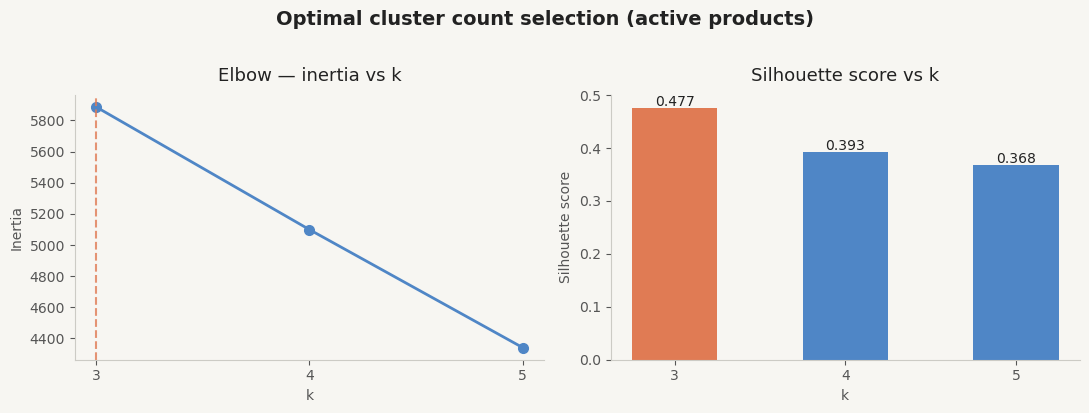

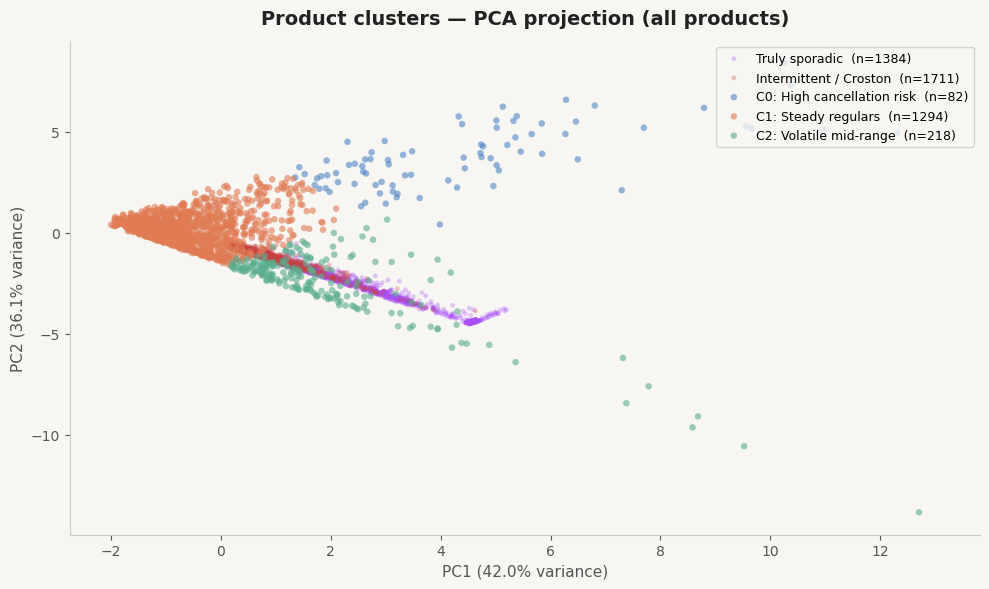

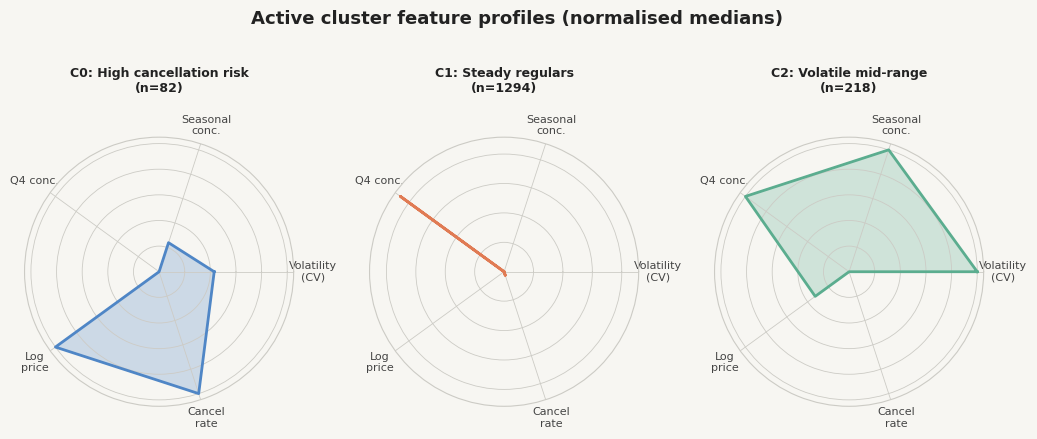

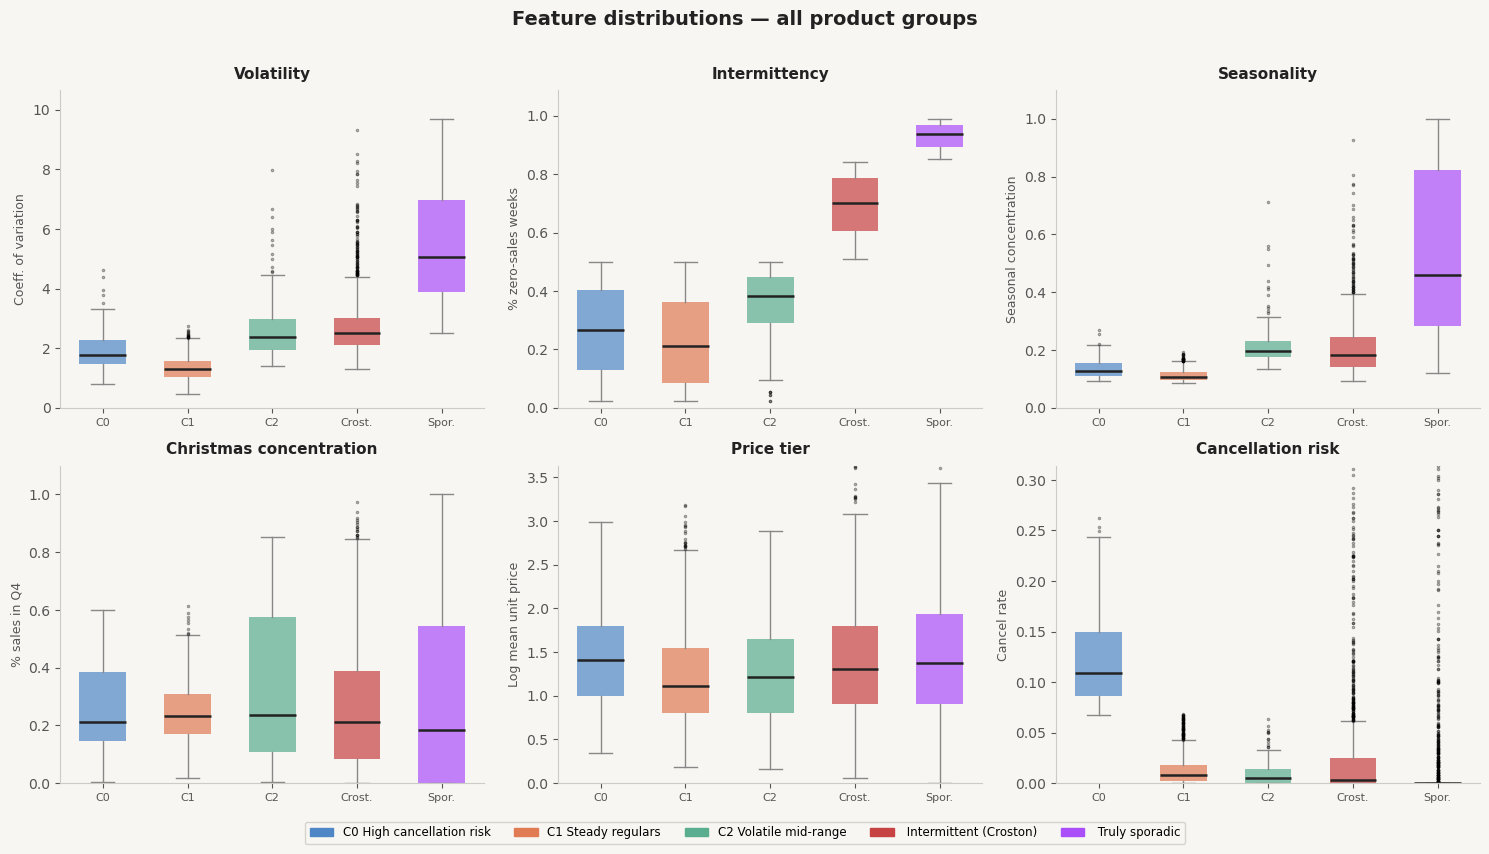

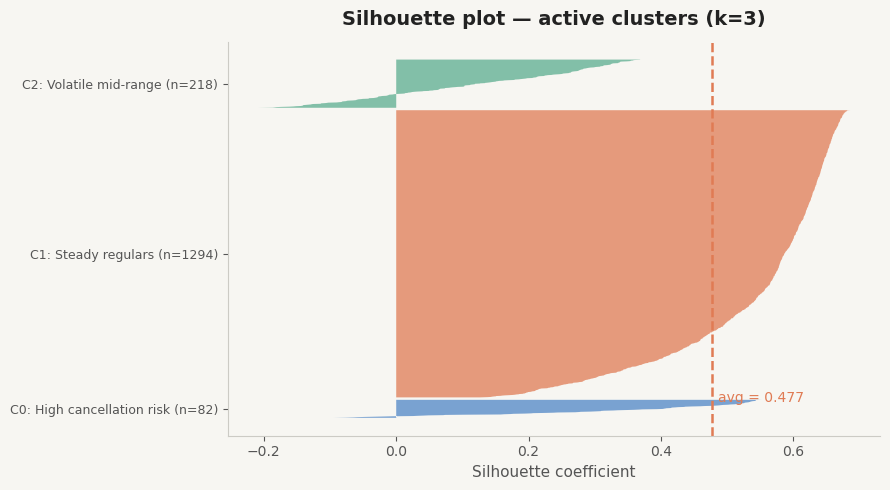

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
warnings.filterwarnings("ignore")

# ── 0. Load scaled features ───────────────────────────────────────────────────

X = feat_scaled[CLUSTERING_COLS].values

# ── 1. Choose optimal k via elbow + silhouette (active products only) ─────────

k_range    = range(3, 6)
inertias   = []
sil_scores = []
models     = {}

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    models[k] = (km, labels)

best_k               = k_range.start + int(np.argmax(sil_scores))
best_km, best_labels = models[best_k]

print(f"Optimal k = {best_k}  (silhouette = {max(sil_scores):.3f})")
for k, s in zip(k_range, sil_scores):
    print(f"  k={k}: {s:.3f}{' <-- best' if k == best_k else ''}")

# Attach cluster labels (0-based) to active products only
feat_df_active = feat_df_active.copy()
feat_df_active.loc[feat_scaled.index, "cluster"] = best_labels
feat_scaled["cluster"] = best_labels

# ── 2. Cluster summary (active only) ─────────────────────────────────────────

summary = feat_df_active.groupby("cluster")[CLUSTERING_COLS].median()
summary["n_products"] = feat_df_active.groupby("cluster").size()
print("\nCluster medians:")
print(summary.to_string())

# ── 3. Auto-label active clusters ────────────────────────────────────────────

def auto_label(row):
    if row.get("cancel_rate", 0) > summary["cancel_rate"].quantile(0.75):
        return "High cancellation risk"
    if row.get("q4_pct", 0) > 0.35 and row.get("seasonal_conc", 0) > 0.18:
        return "Christmas / seasonal"
    if row.get("cv", 0) < summary["cv"].median() and row.get("cancel_rate", 0) < 0.05:
        return "Steady regulars"
    if row.get("cv", 0) >= summary["cv"].median():
        return "Volatile mid-range"
    return "Steady mid-range"

cluster_labels = {i: auto_label(summary.loc[i]) for i in summary.index}
print("\nCluster labels:")
for k, v in cluster_labels.items():
    print(f"  Cluster {k}: {v}  (n={int(summary.loc[k, 'n_products'])})")

# ── 4. Build complete labelled dataframe (all products) ───────────────────────

feat_df_active["cluster_label"] = feat_df_active["cluster"].map(cluster_labels)
feat_df_all = pd.concat([feat_df_active, feat_df_croston, feat_df_sporadic])

# Unified palette — k-means clusters get 0-based keys,
# Croston = -1, Truly sporadic = -2
PALETTE_KMEANS = {0: "#4F86C6", 1: "#E07B54", 2: "#5BAD8F", 3: "#C97EB8"}
PALETTE_FIXED  = {-1: "#C74242", -2: "#AA4EFA"}
PALETTE        = {**PALETTE_KMEANS, **PALETTE_FIXED}

LABEL_MAP = {**cluster_labels, -1: "Intermittent (Croston)", -2: "Truly sporadic"}
BG = "#F7F6F2"

# ── Figure 1: k selection ─────────────────────────────────────────────────────

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig1.patch.set_facecolor(BG)
for ax in (ax1, ax2):
    ax.set_facecolor(BG)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCBC5")
    ax.tick_params(colors="#555")

ks = list(k_range)
ax1.plot(ks, inertias, "o-", color="#4F86C6", lw=2, ms=7)
ax1.axvline(best_k, color="#E07B54", lw=1.5, ls="--", alpha=0.8)
ax1.set_title("Elbow — inertia vs k", fontsize=13, pad=10, color="#222")
ax1.set_xlabel("k", color="#555"); ax1.set_ylabel("Inertia", color="#555")
ax1.set_xticks(ks)

bar_colors = ["#E07B54" if k == best_k else "#4F86C6" for k in ks]
ax2.bar(ks, sil_scores, color=bar_colors, width=0.5, edgecolor="none")
ax2.set_title("Silhouette score vs k", fontsize=13, pad=10, color="#222")
ax2.set_xlabel("k", color="#555"); ax2.set_ylabel("Silhouette score", color="#555")
ax2.set_xticks(ks)
for k, s in zip(ks, sil_scores):
    ax2.text(k, s + 0.003, f"{s:.3f}", ha="center", fontsize=10, color="#222")

fig1.suptitle("Optimal cluster count selection (active products)",
              fontsize=14, y=1.02, color="#222", fontweight="bold")
fig1.tight_layout()
fig1.savefig("fig1_k_selection.png", dpi=150, bbox_inches="tight",
             facecolor=fig1.get_facecolor())
print("\nSaved fig1_k_selection.png")

# ── Figure 2: PCA scatter — ALL groups including fixed ───────────────────────
# PCA fitted on active products; Croston & sporadic projected into same space

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)   # active products
var   = pca.explained_variance_ratio_

# Project the fixed groups using the same PCA
X_croston  = feat_df_croston[CLUSTERING_COLS].fillna(feat_df_active[CLUSTERING_COLS].median()).values
X_sporadic = feat_df_sporadic[CLUSTERING_COLS].fillna(feat_df_active[CLUSTERING_COLS].median()).values
X_croston_pca  = pca.transform(X_croston)
X_sporadic_pca = pca.transform(X_sporadic)

fig2, ax = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCBC5")

# Plot fixed groups first (background)
ax.scatter(X_sporadic_pca[:, 0], X_sporadic_pca[:, 1],
           c=PALETTE[-2], alpha=0.3, s=12, edgecolors="none",
           label=f"Truly sporadic  (n={len(feat_df_sporadic)})")
ax.scatter(X_croston_pca[:, 0], X_croston_pca[:, 1],
           c=PALETTE[-1], alpha=0.3, s=12, edgecolors="none",
           label=f"Intermittent / Croston  (n={len(feat_df_croston)})")

# Plot k-means clusters on top
for c in range(best_k):
    mask = best_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=PALETTE[c], alpha=0.6, s=22, edgecolors="none",
               label=f"C{c}: {cluster_labels[c]}  (n={mask.sum()})")

ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% variance)", color="#555", fontsize=11)
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% variance)", color="#555", fontsize=11)
ax.set_title("Product clusters — PCA projection (all products)",
             fontsize=14, pad=12, color="#222", fontweight="bold")
ax.legend(frameon=True, facecolor=BG, edgecolor="#CCCBC5", fontsize=9, loc="upper right")
ax.tick_params(colors="#555")
fig2.tight_layout()
fig2.savefig("fig2_pca_scatter.png", dpi=150, bbox_inches="tight",
             facecolor=fig2.get_facecolor())
print("Saved fig2_pca_scatter.png")

# ── Figure 3: Radar chart — active clusters only (fixed groups have no variance) ──

radar_label_map = {
    "cv":           "Volatility\n(CV)",
    "seasonal_conc":"Seasonal\nconc.",
    "q4_pct":       "Q4 conc.",
    "log_mean_price":"Log\nprice",
    "cancel_rate":  "Cancel\nrate",
}
radar_features = CLUSTERING_COLS
radar_labels   = [radar_label_map.get(c, c) for c in radar_features]

medians = feat_df_active.groupby("cluster")[radar_features].median()
normed  = (medians - medians.min()) / (medians.max() - medians.min() + 1e-9)

N      = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig3, axes = plt.subplots(1, best_k, figsize=(3.5 * best_k, 4.2),
                           subplot_kw=dict(polar=True))
fig3.patch.set_facecolor(BG)
if best_k == 1:
    axes = [axes]

for c, ax in enumerate(axes):
    raw_vals = medians.loc[c]
    # If all normalised values are < 0.05 the cluster sits at the minimum
    # on every axis — annotate rather than show a misleading flat shape
    vals = normed.loc[c].tolist() + normed.loc[c].tolist()[:1]
    is_flat = all(v < 0.05 for v in normed.loc[c].tolist())
    ax.set_facecolor(BG)
    ax.plot(angles, vals, color=PALETTE[c], lw=2)
    ax.fill(angles, vals, color=PALETTE[c], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8, color="#444")
    ax.set_yticklabels([])
    ax.grid(color="#CCCBC5", lw=0.6)
    ax.spines["polar"].set_color("#CCCBC5")
    ax.set_title(f"C{c}: {cluster_labels[c]}\n(n={int(summary.loc[c, 'n_products'])})",
                 fontsize=9, pad=16, color="#222", fontweight="bold")
    if is_flat:
        ax.text(0, 0, "Baseline cluster\n(lowest on all axes)",
                ha="center", va="center", fontsize=8,
                color="#555", style="italic",
                transform=ax.transData)

fig3.suptitle("Active cluster feature profiles (normalised medians)",
              fontsize=13, y=1.05, color="#222", fontweight="bold")
fig3.tight_layout()
fig3.savefig("fig3_radar.png", dpi=150, bbox_inches="tight",
             facecolor=fig3.get_facecolor())
print("Saved fig3_radar.png")

# ── Figure 4: Box plots — ALL groups side by side ────────────────────────────

# Features to plot and their display names
plot_specs = [
    ("cv",            "Coeff. of variation",    "Volatility"),
    ("pct_zero_weeks","% zero-sales weeks",      "Intermittency"),
    ("seasonal_conc", "Seasonal concentration",  "Seasonality"),
    ("q4_pct",        "% sales in Q4",           "Christmas concentration"),
    ("log_mean_price","Log mean unit price",      "Price tier"),
    ("cancel_rate",   "Cancel rate",             "Cancellation risk"),
]

# All group ids in display order: k-means first, then Croston, then sporadic
all_cluster_ids   = list(range(best_k)) + [-1, -2]
all_cluster_names = [LABEL_MAP[c] for c in all_cluster_ids]
all_colors        = [PALETTE[c] for c in all_cluster_ids]

ncols = 3
nrows = (len(plot_specs) + ncols - 1) // ncols
fig4, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
fig4.patch.set_facecolor(BG)
axes = axes.flatten()

for i, (col, ylabel, title) in enumerate(plot_specs):
    ax = axes[i]
    ax.set_facecolor(BG)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#CCCBC5")
    ax.tick_params(colors="#555")

    data_by_group = [
        feat_df_all[feat_df_all["cluster"] == cid][col].dropna().values
        for cid in all_cluster_ids
    ]
    bp = ax.boxplot(
        data_by_group,
        patch_artist=True,
        medianprops=dict(color="#222", lw=1.8),
        whiskerprops=dict(color="#888"),
        capprops=dict(color="#888"),
        flierprops=dict(marker=".", color="#aaa", ms=3, alpha=0.4),
        widths=0.55,
    )
    for patch, color in zip(bp["boxes"], all_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor("none")

    n_groups = len(all_cluster_ids)
    ax.set_xticks(range(1, n_groups + 1))
    ax.set_xticklabels(
        [f"C{c}" if c >= 0 else ("Crost." if c == -1 else "Spor.")
         for c in all_cluster_ids],
        fontsize=8, color="#555"
    )
    ax.set_ylabel(ylabel, fontsize=9, color="#555")
    ax.set_title(title, fontsize=11, pad=8, color="#222", fontweight="bold")
    cap = np.nanpercentile(feat_df_all[col].dropna().values, 99)
    ax.set_ylim(bottom=0, top=cap * 1.1)

# Hide any unused axes
for j in range(len(plot_specs), len(axes)):
    axes[j].set_visible(False)

fig4.suptitle("Feature distributions — all product groups",
              fontsize=14, y=1.01, color="#222", fontweight="bold")

legend_patches = [
    mpatches.Patch(color=PALETTE[c], label=f"{'C'+str(c) if c>=0 else ''} {LABEL_MAP[c]}")
    for c in all_cluster_ids
]
fig4.legend(handles=legend_patches, loc="lower center",
            ncol=len(all_cluster_ids), fontsize=8.5,
            frameon=True, facecolor=BG, edgecolor="#CCCBC5",
            bbox_to_anchor=(0.5, -0.04))
fig4.tight_layout()
fig4.savefig("fig4_boxplots.png", dpi=150, bbox_inches="tight",
             facecolor=fig4.get_facecolor())
print("Saved fig4_boxplots.png")

# ── Figure 5: Silhouette — active clusters only ───────────────────────────────

sil_vals = silhouette_samples(X, best_labels)
fig5, ax = plt.subplots(figsize=(9, 5))
fig5.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCBC5")

y_lower = 10
ytick_pos, ytick_lbl = [], []
for c in range(best_k):
    c_sil   = np.sort(sil_vals[best_labels == c])
    y_upper = y_lower + len(c_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=PALETTE[c], alpha=0.75, edgecolor="none")
    ytick_pos.append((y_lower + y_upper) / 2)
    ytick_lbl.append(f"C{c}: {cluster_labels[c]} (n={len(c_sil)})")
    y_lower = y_upper + 10

avg_sil = silhouette_score(X, best_labels)
ax.axvline(avg_sil, color="#E07B54", lw=1.8, ls="--")
ax.text(avg_sil + 0.01, y_lower * 0.05, f"avg = {avg_sil:.3f}",
        color="#E07B54", fontsize=10)
ax.set_yticks(ytick_pos)
ax.set_yticklabels(ytick_lbl, fontsize=9, color="#555")
ax.set_xlabel("Silhouette coefficient", color="#555", fontsize=11)
ax.set_title(f"Silhouette plot — active clusters (k={best_k})",
             fontsize=14, pad=12, color="#222", fontweight="bold")
ax.tick_params(colors="#555")
fig5.tight_layout()
fig5.savefig("fig5_silhouette.png", dpi=150, bbox_inches="tight",
             facecolor=fig5.get_facecolor())
print("Saved fig5_silhouette.png")

# ── 5. Save labelled output ───────────────────────────────────────────────────

feat_df_all.to_csv("clustering data/product_features_clustered.csv")
print(f"\nSaved product_features_clustered.csv")
print(f"  Active clustered:        {len(feat_df_active)}  ({best_k} clusters)")
print(f"  Intermittent / Croston:  {len(feat_df_croston)}")
print(f"  Truly sporadic:          {len(feat_df_sporadic)}")
print(f"  Total:                   {len(feat_df_all)}")

# Data Transformation

In [14]:
from itertools import product as iterproduct

# ─────────────────────────────────────────────────────────────────────────────
# ASSUMPTIONS / INPUTS EXPECTED FROM PRIOR STEPS
#
#   retail_train   : raw training transactions (from your train/test split)
#   retail_test    : raw test transactions
#   feat_df_all    : full feature table with columns:
#                      cluster (-2=sporadic, -1=croston, 0..k active)
#                      cluster_label
#                      all feature columns (cv, q4_pct, etc.)
#   CLUSTERING_COLS: list of feature column names used in clustering
#   all_weeks      : full pd.PeriodRange covering the dataset
#   training_weeks : PeriodRange for train split
#   test_weeks     : PeriodRange for test split (last 12 weeks)
#
# ─────────────────────────────────────────────────────────────────────────────

# ── 0. Shared config ──────────────────────────────────────────────────────────

# Static product features to carry into every panel row
# These come from feat_df_all — add/remove as needed
PRODUCT_FEATURE_COLS = [
    "cv",
    "pct_zero_weeks",
    "q4_pct",
    "q1_pct",
    "seasonal_conc",
    "log_mean_weekly_sales",
    "log_mean_price",
    "n_unique_customers",
    "cancel_rate",
    "trend_log_diff",
]

# Lag windows (in weeks) to compute for each product
LAG_WINDOWS       = [1, 2, 4, 8, 13, 26, 52]
ROLL_WINDOWS      = [4, 8, 13, 26]

# ── 1. Aggregate raw transactions → weekly sales per product ──────────────────

def make_weekly_actuals(transactions):
    """
    Aggregate raw transaction rows to weekly revenue per StockCode.
    Returns a long dataframe: StockCode | week (Period) | sales
    """
    df = transactions.copy()
    df["week"] = df["InvoiceDate"].dt.to_period("W")

    weekly = (
        df.groupby(["StockCode", "week"])["Sales"]
        .sum()
        .reset_index()
        .rename(columns={"Sales": "sales"})
    )
    return weekly


# ── 2. Calendar feature builder ───────────────────────────────────────────────

def _weeks_to_christmas(ts):
    """Weeks remaining until Christmas, capped at 26."""
    xmas = pd.Timestamp(f"{ts.year}-12-25")
    diff = (xmas - ts).days / 7
    if diff < 0:
        xmas = pd.Timestamp(f"{ts.year + 1}-12-25")
        diff = (xmas - ts).days / 7
    return round(min(26, max(0, diff)), 2)


def _easter_weeks(years):
    """Return set of week-start dates that contain Easter (Good Fri - Mon)."""
    try:
        import holidays
        easter_dates = set()
        for year in years:
            uk = holidays.UK(years=year)
            for d, name in uk.items():
                if "Easter" in name:
                    # include the full week around Easter
                    ts = pd.Timestamp(d)
                    for offset in range(-3, 4):
                        easter_dates.add((ts + pd.Timedelta(days=offset)).date())
        return easter_dates
    except ImportError:
        return set()


def add_calendar_features(df, date_col="week_start"):
    """
    df must have a column `date_col` of pd.Timestamp (week start date).
    Adds all calendar features in-place and returns df.
    """
    dates = df[date_col]

    df["week_of_year"]      = dates.dt.isocalendar().week.astype(int)
    df["month"]             = dates.dt.month
    df["quarter"]           = dates.dt.quarter
    df["year"]              = dates.dt.year

    # Smooth cyclical encodings — prevent model treating wk52 and wk1 as far apart
    df["sin_week"]          = np.sin(2 * np.pi * df["week_of_year"] / 52)
    df["cos_week"]          = np.cos(2 * np.pi * df["week_of_year"] / 52)
    df["sin_month"]         = np.sin(2 * np.pi * df["month"] / 12)
    df["cos_month"]         = np.cos(2 * np.pi * df["month"] / 12)

    # Retail calendar flags
    df["is_christmas_week"] = df["week_of_year"].isin([51, 52]).astype(int)
    df["is_peak_season"]    = (df["week_of_year"] >= 44).astype(int)
    df["weeks_to_christmas"]= dates.apply(_weeks_to_christmas)

    # Q1 occasion flags (Valentine's / Easter)
    df["is_valentines"]     = (
        (df["month"] == 2) & (dates.dt.day <= 14)
    ).astype(int)

    easter_dates = _easter_weeks(dates.dt.year.unique())
    if easter_dates:
        df["is_easter"] = dates.apply(
            lambda d: int(d.date() in easter_dates)
        )
    else:
        df["is_easter"] = 0

    return df


# ── 3. Build the product × week spine ────────────────────────────────────────

def build_spine(stock_codes, week_range):
    weeks_list = list(week_range)
    rows = list(iterproduct(stock_codes, weeks_list))
    spine = pd.DataFrame(rows, columns=["StockCode", "week"])
    spine["week_start"] = spine["week"].apply(lambda p: p.start_time.normalize())
    # week_key used for reliable string-based .isin() matching
    spine["week_key"]   = spine["week_start"].dt.strftime("%Y-%m-%d")
    return spine


# ── 4. Attach actuals and product features ────────────────────────────────────

def attach_actuals(spine, weekly_actuals):
    """
    Left-join actual weekly sales onto spine.
    Missing weeks (no sales) → 0.
    """
    panel = spine.merge(weekly_actuals, on=["StockCode", "week"], how="left")
    panel["sales"] = panel["sales"].fillna(0.0)
    return panel


def attach_product_features(panel, feat_df, feature_cols):
    """
    Merge static product-level features from feat_df.
    These are constant across all weeks for a given product.
    """
    prod_feats = (
        feat_df[feature_cols]
        .reset_index()                    # StockCode becomes a column
        .rename(columns={"index": "StockCode"})
    )
    # feat_df index is StockCode
    prod_feats = feat_df[feature_cols].copy()
    prod_feats.index.name = "StockCode"
    prod_feats = prod_feats.reset_index()

    panel = panel.merge(prod_feats, on="StockCode", how="left")
    return panel


# ── 5. Lag and rolling features ───────────────────────────────────────────────

def add_lag_features(panel, lag_windows=LAG_WINDOWS, roll_windows=ROLL_WINDOWS):
    """
    Compute per-product lags and rolling means.
    IMPORTANT: all lags use shift(n) so they reference strictly past data.
    Panel must be sorted by StockCode, week before calling.
    """
    df = panel.sort_values(["StockCode", "week"]).copy()
    grp = df.groupby("StockCode")["sales"]

    for lag in lag_windows:
        df[f"lag_{lag}w"] = grp.shift(lag)

    for window in roll_windows:
        # shift(1) before rolling ensures we never include the current week
        df[f"roll_mean_{window}w"] = (
            grp.transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
        )

    # Same-week last year rolling average — strong seasonal anchor
    df["lag_52w_roll4"] = (
        grp.transform(lambda x: x.shift(52).rolling(4, min_periods=1).mean())
    )

    # Short trend: recent 4-week mean minus prior 4-week mean
    df["short_trend"] = (
        grp.transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
        - grp.transform(lambda x: x.shift(5).rolling(4, min_periods=1).mean())
    )

    return df


# ── 6. Master panel builder per cluster ──────────────────────────────────────

def build_cluster_panel(
    cluster_id,
    feat_df_all,
    retail_train,
    retail_test,
    training_weeks,
    test_weeks,
    all_weeks,
    product_feature_cols=PRODUCT_FEATURE_COLS,
    min_lag_for_training=52,    # drop rows where lag_52w is NaN
):
    """
    Builds train and test panels for a single cluster.

    Returns
    -------
    train_panel : pd.DataFrame — rows with full lag history, target = sales
    test_panel  : pd.DataFrame — future rows for evaluation / forecasting
    feature_cols: list[str]    — column names to pass as model features (X)
    """
    cluster_products = feat_df_all[feat_df_all["cluster"] == cluster_id].index.tolist()
    n = len(cluster_products)
    label = feat_df_all[feat_df_all["cluster"] == cluster_id]["cluster_label"].iloc[0]
    print(f"\n── Cluster {cluster_id}: '{label}'  ({n} products) ──")

    if n == 0:
        print("  No products — skipping.")
        return None, None, None

       # ── a. Weekly actuals from BOTH train and test transactions ───────────────
    # Train actuals feed lag features; test actuals are the evaluation target.
    # We combine both so the spine join populates real sales for test weeks.
    # The train/test split happens later in step g — the model never sees
    # test actuals during training because we split before fitting.
    all_actuals = make_weekly_actuals(
        pd.concat([
            retail_train[retail_train["StockCode"].isin(cluster_products)],
            retail_test[retail_test["StockCode"].isin(cluster_products)]
        ])
    )

    # ── b. Build spine covering ALL weeks (train + test) ──────────────────────
    # We need test weeks in the spine so lags from history can be attached
    full_spine = build_spine(cluster_products, all_weeks)

    # ── c. Attach actuals — test weeks now have real sales values ─────────────
    panel = attach_actuals(full_spine, all_actuals)

    # ── d. Calendar features ──────────────────────────────────────────────────
    panel = add_calendar_features(panel, date_col="week_start")

    # ── e. Product (static) features ──────────────────────────────────────────
    available_feat_cols = [c for c in product_feature_cols if c in feat_df_all.columns]
    panel = attach_product_features(panel, feat_df_all, available_feat_cols)

    # ── f. Lag features (computed across full timeline so test rows get lags) ─
    panel = add_lag_features(panel)

    # ── g. Split into train / test ────────────────────────────────────────────────
    train_mask = panel["week"].isin(set(training_weeks))
    test_mask  = panel["week"].isin(set(test_weeks))

    train_panel = panel[train_mask].copy()
    test_panel  = panel[test_mask].copy()

    # ── h. Drop training rows where lag_52w is NaN ───────────────────────────
    # These are the first 52 weeks where we have no year-ago anchor.
    # Keeping them would force the model to learn from incomplete lag sets.
    before = len(train_panel)
    train_panel = train_panel.dropna(subset=["lag_52w"])
    after  = len(train_panel)
    print(f"  Dropped {before - after} train rows (lag_52w NaN) — {after} remain")

    # ── i. Identify feature columns ───────────────────────────────────────────
    exclude = {"StockCode", "week", "week_start", "sales",
               "cluster", "cluster_label", "is_sporadic",
               "is_croston", "is_active"}
    feature_cols = [c for c in train_panel.columns if c not in exclude]

    print(f"  Train rows : {len(train_panel):,}  |  "
          f"Test rows : {len(test_panel):,}  |  "
          f"Features : {len(feature_cols)}")

    # At the end of build_cluster_panel, confirm train_panel
    # is the post-drop version before returning
    print(f"  Returning train_panel with {len(train_panel)} rows (post lag_52w drop)")
    return train_panel, test_panel, feature_cols


# ── 7. Run for all clusters ───────────────────────────────────────────────────

def build_all_panels(
    feat_df_all,
    retail_train,
    retail_test,
    training_weeks,
    test_weeks,
    all_weeks,
    product_feature_cols=PRODUCT_FEATURE_COLS,
):
    """
    Iterates over every unique cluster id in feat_df_all and builds panels.

    Returns
    -------
    panels : dict mapping cluster_id ->
                 {"train": df, "test": df, "features": list[str], "label": str}
    """
    cluster_ids = sorted(feat_df_all["cluster"].unique())
    panels = {}

    for cid in cluster_ids:
        label = feat_df_all[feat_df_all["cluster"] == cid]["cluster_label"].iloc[0]
        train_panel, test_panel, feature_cols = build_cluster_panel(
            cluster_id          = cid,
            feat_df_all         = feat_df_all,
            retail_train        = retail_train,
            retail_test         = retail_test,
            training_weeks      = training_weeks,
            test_weeks          = test_weeks,
            all_weeks           = all_weeks,
            product_feature_cols= product_feature_cols,
        )

        if train_panel is not None:
            panels[cid] = {
                "train"   : train_panel,
                "test"    : test_panel,
                "features": feature_cols,
                "label"   : label,
            }

    return panels


# ── 8. Entry point ────────────────────────────────────────────────────────────
# Build panels for every cluster
panels = build_all_panels(
    feat_df_all    = feat_df_all,
    retail_train   = retail_train,
    retail_test    = retail_test,
    training_weeks = training_weeks,
    test_weeks     = test_weeks,
    all_weeks      = all_weeks,
)

# Quick summary
print("\n── Panel summary ────────────────────────────────────────────────")
for cid, p in panels.items():
    print(
        f"  Cluster {cid:>2} | {p['label']:<30} | "
        f"train={len(p['train']):>7,} rows | "
        f"test={len(p['test']):>6,} rows | "
        f"{len(p['features'])} features"
    )

# Access individual cluster panels like this:
#
#   train      = panels[0]["train"]
#   test       = panels[0]["test"]
#   feat_cols  = panels[0]["features"]
#
#   X_train    = train[feat_cols]
#   y_train    = train["sales"]
#
#   X_test     = test[feat_cols]
#   y_test     = test["sales"]   # actuals for evaluation
#
# Croston / sporadic clusters (cluster -1, -2) also get panels built
# but you won't train LightGBM on them — use Croston's method instead.
# Their panels are still useful for holding the lag history needed
# by the recursive forecaster.

print("\nDone. All panels ready.")


── Cluster -2.0: 'Truly sporadic'  (1384 products) ──
  Dropped 71968 train rows (lag_52w NaN) — 58128 remain
  Train rows : 58,128  |  Test rows : 16,608  |  Features : 37
  Returning train_panel with 58128 rows (post lag_52w drop)

── Cluster -1.0: 'Intermittent (Croston)'  (1711 products) ──
  Dropped 88972 train rows (lag_52w NaN) — 71862 remain
  Train rows : 71,862  |  Test rows : 20,532  |  Features : 37
  Returning train_panel with 71862 rows (post lag_52w drop)

── Cluster 0.0: 'High cancellation risk'  (82 products) ──
  Dropped 4264 train rows (lag_52w NaN) — 3444 remain
  Train rows : 3,444  |  Test rows : 984  |  Features : 37
  Returning train_panel with 3444 rows (post lag_52w drop)

── Cluster 1.0: 'Steady regulars'  (1294 products) ──
  Dropped 67288 train rows (lag_52w NaN) — 54348 remain
  Train rows : 54,348  |  Test rows : 15,528  |  Features : 37
  Returning train_panel with 54348 rows (post lag_52w drop)

── Cluster 2.0: 'Volatile mid-range'  (218 products) ──
 

##   Cluster -2.0 | Truly sporadic

Sporadic train rows : 58,128
Sporadic test rows  : 16,608
Sporadic products   : 1,384

Fitting forecasts for 1,384 sporadic products...

Test week segments:
  Segment 1: 2011-09-19/2011-09-25 → 2011-10-03/2011-10-09  (3 weeks)
  Segment 2: 2011-10-10/2011-10-16 → 2011-10-24/2011-10-30  (3 weeks)
  Segment 3: 2011-10-31/2011-11-06 → 2011-11-14/2011-11-20  (3 weeks)
  Segment 4: 2011-11-21/2011-11-27 → 2011-12-05/2011-12-11  (3 weeks)

Forecast rows: 16,608

Truly Sporadic Cluster — Segmented MAPE (APE capped at 1000%):
  Segment  Weeks  % Zero Actuals  MAPE Seasonal Naïve  MAPE Nonzero Mean  MAPE Croston SBA  MAPE ADIDA
Segment 1      3            82.1               100.45              96.97             91.55       91.72
Segment 2      3            82.5               100.91             136.96             91.30       91.64
Segment 3      3            81.0               104.96             114.22             91.40       91.35
Segment 4      3            80.9                98.48           

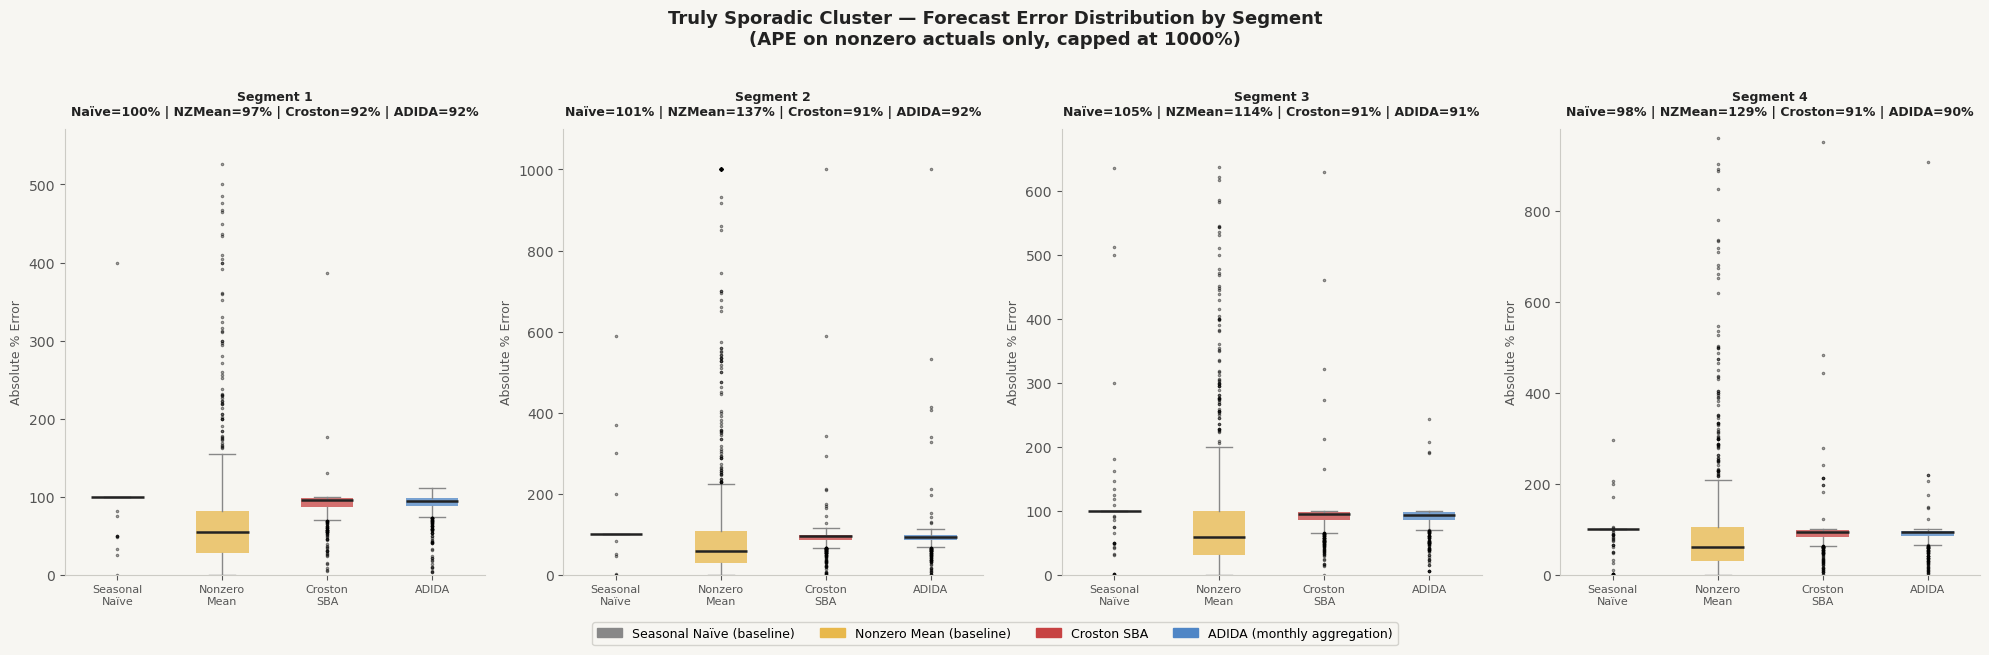

Saved: sporadic_forecasts.csv

── Truly Sporadic Cluster — Final Summary ───────────────────────
  Products       : 1,384
  Test weeks     : 12
  % zero actuals : 81.6%
  APE cap        : 1000%

  Overall MAPE comparison:
    Seasonal Naïve : 101.22%
    Nonzero Mean   : 119.26%
    Croston SBA    : 91.23%
    ADIDA          : 91.17%

  Winner : ADIDA  (MAPE = 91.17%)


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

Path("forecast figs").mkdir(exist_ok=True)

# ── 0. Config ─────────────────────────────────────────────────────────────────
SPORADIC_CLUSTER_ID = -2
N_SEGMENTS          = 4         # 4 segments × 3 weeks = 12 test weeks
APE_CAP             = 1000.0    # cap individual APE at 1000% — standard for
                                 # intermittent demand reporting
BG                  = "#F7F6F2"
PALETTE             = {
    "naive"   : "#888888",
    "nz_mean" : "#E8B84B",
    "croston" : "#C74242",
    "adida"   : "#4F86C6",
}

# ── 1. Pull sporadic panel ────────────────────────────────────────────────────
sporadic_train = panels[SPORADIC_CLUSTER_ID]["train"]
sporadic_test  = panels[SPORADIC_CLUSTER_ID]["test"]

print(f"Sporadic train rows : {len(sporadic_train):,}")
print(f"Sporadic test rows  : {len(sporadic_test):,}")
print(f"Sporadic products   : {sporadic_train['StockCode'].nunique():,}")


# ── 2. MAPE utilities ─────────────────────────────────────────────────────────

def mape(actual, forecast, cap=APE_CAP):
    """
    MAPE on nonzero actuals only — standard for intermittent demand.
    Individual APE values capped at `cap` percent to prevent extreme
    observations dominating the aggregate metric.
    Returns value on 0-100 scale as required by assignment.
    """
    actual   = np.array(actual,   dtype=float)
    forecast = np.array(forecast, dtype=float)
    mask     = actual > 0
    if mask.sum() == 0:
        return np.nan
    ape = np.abs(actual[mask] - forecast[mask]) / actual[mask] * 100
    ape = np.clip(ape, 0, cap)
    return float(np.mean(ape))


def ape_series(actual, forecast, cap=APE_CAP):
    """
    Absolute percentage errors for nonzero actuals only.
    Capped at `cap` percent for box plot stability.
    """
    actual   = np.array(actual,   dtype=float)
    forecast = np.array(forecast, dtype=float)
    mask     = actual > 0
    if mask.sum() == 0:
        return np.array([])
    ape = np.abs(actual[mask] - forecast[mask]) / actual[mask] * 100
    return np.clip(ape, 0, cap)


# ── 3. Segment assignment ─────────────────────────────────────────────────────

def assign_segments(df, n_segments=N_SEGMENTS):
    """
    Divides 12 test weeks into n_segments equal chunks.
    Adds a 'segment' column (1-indexed).
    """
    unique_weeks = sorted(df["week"].unique())
    n_weeks      = len(unique_weeks)
    seg_size     = n_weeks // n_segments

    week_to_seg  = {
        w: min(i // seg_size + 1, n_segments)
        for i, w in enumerate(unique_weeks)
    }

    df = df.copy()
    df["segment"] = df["week"].map(week_to_seg)

    print("\nTest week segments:")
    for seg in range(1, n_segments + 1):
        seg_weeks = [w for w, s in week_to_seg.items() if s == seg]
        print(f"  Segment {seg}: {min(seg_weeks)} → {max(seg_weeks)}  ({len(seg_weeks)} weeks)")

    return df


# ── 4. SBA Croston implementation ─────────────────────────────────────────────

def croston_sba(series, alpha=0.1):
    """
    Syntetos-Boylan Approximation (SBA) Croston variant.
    Returns flat weekly forecast rate fitted on training history.
    Capped at 3x historical max to prevent exploding sparse predictions.
    """
    demand = np.array(series, dtype=float)
    nz_idx = np.where(demand > 0)[0]

    if len(nz_idx) == 0:
        return 0.0
    if len(nz_idx) == 1:
        z_hat = demand[nz_idx[0]]
        p_hat = len(demand)
        rate  = (1 - alpha / 2) * z_hat / p_hat
        return min(rate, 3 * demand.max())

    z_hat = demand[nz_idx[0]]
    p_hat = nz_idx[0] + 1 if nz_idx[0] > 0 else 1

    for i in range(1, len(nz_idx)):
        idx      = nz_idx[i]
        prev_idx = nz_idx[i - 1]
        interval = idx - prev_idx
        z_hat    = alpha * demand[idx] + (1 - alpha) * z_hat
        p_hat    = alpha * interval    + (1 - alpha) * p_hat

    if p_hat == 0:
        return 0.0

    rate = (1 - alpha / 2) * z_hat / p_hat
    return min(rate, 3 * demand.max())


# ── 5. ADIDA implementation ───────────────────────────────────────────────────
#
# ADIDA (Aggregation-Disaggregation Intermittent Demand Approach) works
# in three steps per product:
#
# Step 1 — AGGREGATE:
#   Sum weekly training sales into monthly buckets. Monthly series has
#   far fewer zeros than weekly, giving Croston more signal to work with.
#   E.g. weekly [0,0,0,50,0,0,0,30,0,0,0,0] → monthly [50, 30, 0]
#
# Step 2 — FIT:
#   Run Croston SBA on the monthly aggregated series to get a monthly
#   forecast rate. The model sees a less sparse series and produces
#   a more reliable estimate.
#
# Step 3 — DISAGGREGATE:
#   Divide the monthly forecast evenly across the weeks in each month.
#   E.g. monthly forecast = 40 → weekly forecast = 40/4 = 10 per week.
#   This gives each test week a forecast derived from the monthly model.

def adida_forecast(weekly_series, week_index, test_week_starts,
                   aggregation_level="monthly"):
    """
    ADIDA forecast for a single product.

    Parameters
    ----------
    weekly_series    : array-like — weekly sales (training period)
    week_index       : array-like — week start dates for training period
    test_week_starts : array-like — week start dates for test period
    aggregation_level: str — 'monthly' or 'quarterly'

    Returns
    -------
    dict : {week_start: forecast_value} for each test week
    """
    # Build training series as a dated Series for resampling
    train_series = pd.Series(
        weekly_series,
        index=pd.DatetimeIndex(week_index)
    )

    # ── Step 1: Aggregate to lower frequency ─────────────────────────────────
    if aggregation_level == "monthly":
        freq    = "ME"       # month-end frequency
        n_weeks = 4.333      # average weeks per month
    else:
        freq    = "QE"       # quarter-end frequency
        n_weeks = 13         # weeks per quarter

    # Sum weekly sales into monthly/quarterly buckets
    agg_series = train_series.resample(freq).sum().values

    # ── Step 2: Fit Croston SBA on aggregated series ──────────────────────────
    # Croston now sees a less sparse series with more signal per observation
    monthly_rate = croston_sba(agg_series, alpha=0.1)

    # ── Step 3: Disaggregate back to weekly ───────────────────────────────────
    # Divide monthly forecast evenly across weeks in each month
    weekly_rate = monthly_rate / n_weeks

    # Apply same flat weekly rate to all test weeks
    return {ws: weekly_rate for ws in test_week_starts}


# ── 6. Fit all forecasts per product ─────────────────────────────────────────

def fit_sporadic_forecasts(train_panel, test_panel):
    """
    For each sporadic product fits four forecast methods:
      - Seasonal Naïve  : lag_52w from test panel
      - Nonzero Mean    : mean of nonzero training weeks
      - Croston SBA     : flat rate fitted on weekly training history
      - ADIDA           : Croston SBA fitted on monthly aggregated history,
                          disaggregated back to weekly

    MAPE computed on nonzero actuals only, APE capped at 1000%.
    """
    results = []

    test_weeks_ordered = (
        test_panel[["week", "week_start"]]
        .drop_duplicates()
        .sort_values("week_start")
        ["week"]
        .tolist()
    )

    test_week_starts = (
        test_panel[["week", "week_start"]]
        .drop_duplicates()
        .sort_values("week_start")
        ["week_start"]
        .tolist()
    )

    products = train_panel["StockCode"].unique()
    print(f"\nFitting forecasts for {len(products):,} sporadic products...")

    # Precompute nonzero mean per product
    def nonzero_mean(x):
        nz = x[x > 0]
        return float(nz.mean()) if len(nz) > 0 else 0.0

    nz_mean_map = (
        train_panel
        .groupby("StockCode")["sales"]
        .apply(nonzero_mean)
        .to_dict()
    )

    # Precompute seasonal naïve per product-week
    naive_map = (
        test_panel
        .groupby(["StockCode", "week"])["lag_52w"]
        .first()
        .fillna(0)
        .clip(lower=0)
        .to_dict()
    )

    for stock_code in products:
        prod_train = (
            train_panel[train_panel["StockCode"] == stock_code]
            .sort_values("week_start")
        )
        train_sales      = prod_train["sales"].values
        train_week_starts = prod_train["week_start"].values

        # ── Croston SBA — weekly ───────────────────────────────────────────────
        croston_rate = croston_sba(train_sales)

        # ── ADIDA — monthly aggregation ───────────────────────────────────────
        adida_map = adida_forecast(
            weekly_series    = train_sales,
            week_index       = train_week_starts,
            test_week_starts = test_week_starts,
            aggregation_level= "monthly",
        )

        # ── Nonzero mean ──────────────────────────────────────────────────────
        nz_mean_rate = nz_mean_map.get(stock_code, 0.0)

        # ── Actuals for test period ───────────────────────────────────────────
        prod_test = (
            test_panel[test_panel["StockCode"] == stock_code]
            .sort_values("week_start")
            .set_index("week")
        )

        for week, week_start in zip(test_weeks_ordered, test_week_starts):
            actual       = float(prod_test["sales"].get(week, 0.0))
            naive_rate   = float(naive_map.get((stock_code, week), 0.0))
            adida_rate   = adida_map.get(week_start, 0.0)

            results.append({
                "StockCode"        : stock_code,
                "week"             : week,
                "actual"           : actual,
                "forecast_naive"   : naive_rate,
                "forecast_nz_mean" : nz_mean_rate,
                "forecast_croston" : croston_rate,
                "forecast_adida"   : adida_rate,
            })

    return pd.DataFrame(results)


sporadic_forecasts = fit_sporadic_forecasts(sporadic_train, sporadic_test)
sporadic_forecasts = assign_segments(sporadic_forecasts)
print(f"\nForecast rows: {len(sporadic_forecasts):,}")


# ── 7. Segmented MAPE table ───────────────────────────────────────────────────

def segmented_mape_table(df, n_segments=N_SEGMENTS):
    """
    MAPE per segment for all four methods.
    APE capped at APE_CAP before averaging.
    Baselines shown first so improvement is clear.
    """
    methods = {
        "Seasonal Naïve" : "forecast_naive",
        "Nonzero Mean"   : "forecast_nz_mean",
        "Croston SBA"    : "forecast_croston",
        "ADIDA"          : "forecast_adida",
    }

    rows = []
    for seg in list(range(1, n_segments + 1)) + ["Overall"]:
        seg_df   = df if seg == "Overall" else df[df["segment"] == seg]
        n_total  = len(seg_df)
        n_zero   = (seg_df["actual"] == 0).sum()
        pct_zero = n_zero / n_total * 100 if n_total > 0 else np.nan

        row = {
            "Segment"        : "Overall" if seg == "Overall" else f"Segment {seg}",
            "Weeks"          : seg_df["week"].nunique(),
            "% Zero Actuals" : round(pct_zero, 1),
        }
        for name, col in methods.items():
            row[f"MAPE {name}"] = round(mape(seg_df["actual"], seg_df[col]), 2)

        rows.append(row)

    return pd.DataFrame(rows)


mape_table = segmented_mape_table(sporadic_forecasts)
print("\nTruly Sporadic Cluster — Segmented MAPE (APE capped at 1000%):")
print(mape_table.to_string(index=False))


# ── 8. Box plots ──────────────────────────────────────────────────────────────

def plot_sporadic_boxplots(df, mape_table, n_segments=N_SEGMENTS):
    """
    Box plots of APE per segment for all four methods.
    APE computed on nonzero actuals only, capped at APE_CAP.
    Saved to forecast figs/sporadic_boxplots.png
    """
    methods = {
        "Seasonal\nNaïve" : ("forecast_naive",    PALETTE["naive"]),
        "Nonzero\nMean"   : ("forecast_nz_mean",  PALETTE["nz_mean"]),
        "Croston\nSBA"    : ("forecast_croston",   PALETTE["croston"]),
        "ADIDA"           : ("forecast_adida",     PALETTE["adida"]),
    }

    fig, axes = plt.subplots(1, n_segments, figsize=(5 * n_segments, 6), sharey=False)
    fig.patch.set_facecolor(BG)

    for seg_idx, seg in enumerate(range(1, n_segments + 1)):
        ax     = axes[seg_idx]
        seg_df = df[df["segment"] == seg]
        ax.set_facecolor(BG)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCBC5")
        ax.tick_params(colors="#555")

        ape_data   = []
        box_colors = []
        for label, (col, color) in methods.items():
            ape_data.append(ape_series(seg_df["actual"], seg_df[col]))
            box_colors.append(color)

        bp = ax.boxplot(
            ape_data,
            patch_artist=True,
            medianprops=dict(color="#222", lw=1.8),
            whiskerprops=dict(color="#888"),
            capprops=dict(color="#888"),
            flierprops=dict(marker=".", color="#aaa", ms=3, alpha=0.5),
            widths=0.5,
        )
        for patch, color in zip(bp["boxes"], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
            patch.set_edgecolor("none")

        seg_row = mape_table[mape_table["Segment"] == f"Segment {seg}"].iloc[0]

        ax.set_xticks(range(1, len(methods) + 1))
        ax.set_xticklabels(list(methods.keys()), fontsize=8, color="#555")
        ax.set_ylabel("Absolute % Error", fontsize=9, color="#555")
        ax.set_title(
            f"Segment {seg}\n"
            f"Naïve={seg_row['MAPE Seasonal Naïve']:.0f}% | "
            f"NZMean={seg_row['MAPE Nonzero Mean']:.0f}% | "
            f"Croston={seg_row['MAPE Croston SBA']:.0f}% | "
            f"ADIDA={seg_row['MAPE ADIDA']:.0f}%",
            fontsize=9, pad=10, color="#222", fontweight="bold"
        )

        all_ape = np.concatenate([a for a in ape_data if len(a) > 0])
        if len(all_ape) > 0:
            cap = np.nanpercentile(all_ape, 99)
            ax.set_ylim(bottom=0, top=cap * 1.1)

    legend_patches = [
        mpatches.Patch(color=PALETTE["naive"],   label="Seasonal Naïve (baseline)"),
        mpatches.Patch(color=PALETTE["nz_mean"], label="Nonzero Mean (baseline)"),
        mpatches.Patch(color=PALETTE["croston"], label="Croston SBA"),
        mpatches.Patch(color=PALETTE["adida"],   label="ADIDA (monthly aggregation)"),
    ]
    fig.legend(
        handles=legend_patches,
        loc="lower center",
        ncol=4,
        fontsize=9,
        frameon=True,
        facecolor=BG,
        edgecolor="#CCCBC5",
        bbox_to_anchor=(0.5, -0.05),
    )
    fig.suptitle(
        "Truly Sporadic Cluster — Forecast Error Distribution by Segment\n"
        f"(APE on nonzero actuals only, capped at {APE_CAP:.0f}%)",
        fontsize=13, y=1.02, color="#222", fontweight="bold"
    )
    fig.tight_layout()

    save_path = "forecast figs/sporadic_boxplots.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"\nSaved: {save_path}")
    plt.show()


plot_sporadic_boxplots(sporadic_forecasts, mape_table)


# ── 9. Save outputs ───────────────────────────────────────────────────────────
sporadic_forecasts.to_csv("clustering data/sporadic_forecasts.csv", index=False)
print("Saved: sporadic_forecasts.csv")


# ── 10. Final summary ─────────────────────────────────────────────────────────
print("\n── Truly Sporadic Cluster — Final Summary ───────────────────────")
print(f"  Products       : {sporadic_forecasts['StockCode'].nunique():,}")
print(f"  Test weeks     : {sporadic_forecasts['week'].nunique()}")
pct_zero = (sporadic_forecasts["actual"] == 0).mean() * 100
print(f"  % zero actuals : {pct_zero:.1f}%")
print(f"  APE cap        : {APE_CAP:.0f}%")

overall = mape_table[mape_table["Segment"] == "Overall"].iloc[0]
print("\n  Overall MAPE comparison:")
print(f"    Seasonal Naïve : {overall['MAPE Seasonal Naïve']:.2f}%")
print(f"    Nonzero Mean   : {overall['MAPE Nonzero Mean']:.2f}%")
print(f"    Croston SBA    : {overall['MAPE Croston SBA']:.2f}%")
print(f"    ADIDA          : {overall['MAPE ADIDA']:.2f}%")

scores = {
    "Seasonal Naïve" : overall["MAPE Seasonal Naïve"],
    "Nonzero Mean"   : overall["MAPE Nonzero Mean"],
    "Croston SBA"    : overall["MAPE Croston SBA"],
    "ADIDA"          : overall["MAPE ADIDA"],
}
winner = min(scores, key=scores.get)
print(f"\n  Winner : {winner}  (MAPE = {scores[winner]:.2f}%)")

## Cluster -1.0 | Intermittent (Croston)

Croston cluster train rows : 71,862
Croston cluster test rows  : 20,532
Croston cluster products   : 1,711
Features (all)             : 37
Features (LightGBM)        : 36

Computing baselines...
  Baseline rows    : 20,532
  % zero actuals   : 60.6%

Fitting SBA Croston for 1,711 products...

Training Two-Stage LightGBM on Croston cluster...
  Stage 1: fitting binary classifier (demand occurrence)...
[100]	valid_0's binary_logloss: 0.334322
  Stage 1 done. Mean P(demand>0) on test: 0.363
  Stage 2: fitting regression on nonzero demand rows only...
  Stage 2 training on 20,636 nonzero rows (28.7% of training data)
[100]	valid_0's l1: 66.3134
[200]	valid_0's l1: 65.7365
[300]	valid_0's l1: 65.5807
  Two-stage forecast done.
  % zero predictions : 0.0%
  Two-stage forecast rows: 20,532

Test week segments:
  Segment 1: 2011-09-19/2011-09-25 → 2011-10-03/2011-10-09  (3 weeks)
  Segment 2: 2011-10-10/2011-10-16 → 2011-10-24/2011-10-30  (3 weeks)
  Segment 3: 2011-10-31/2011-11-06 → 2011-11-

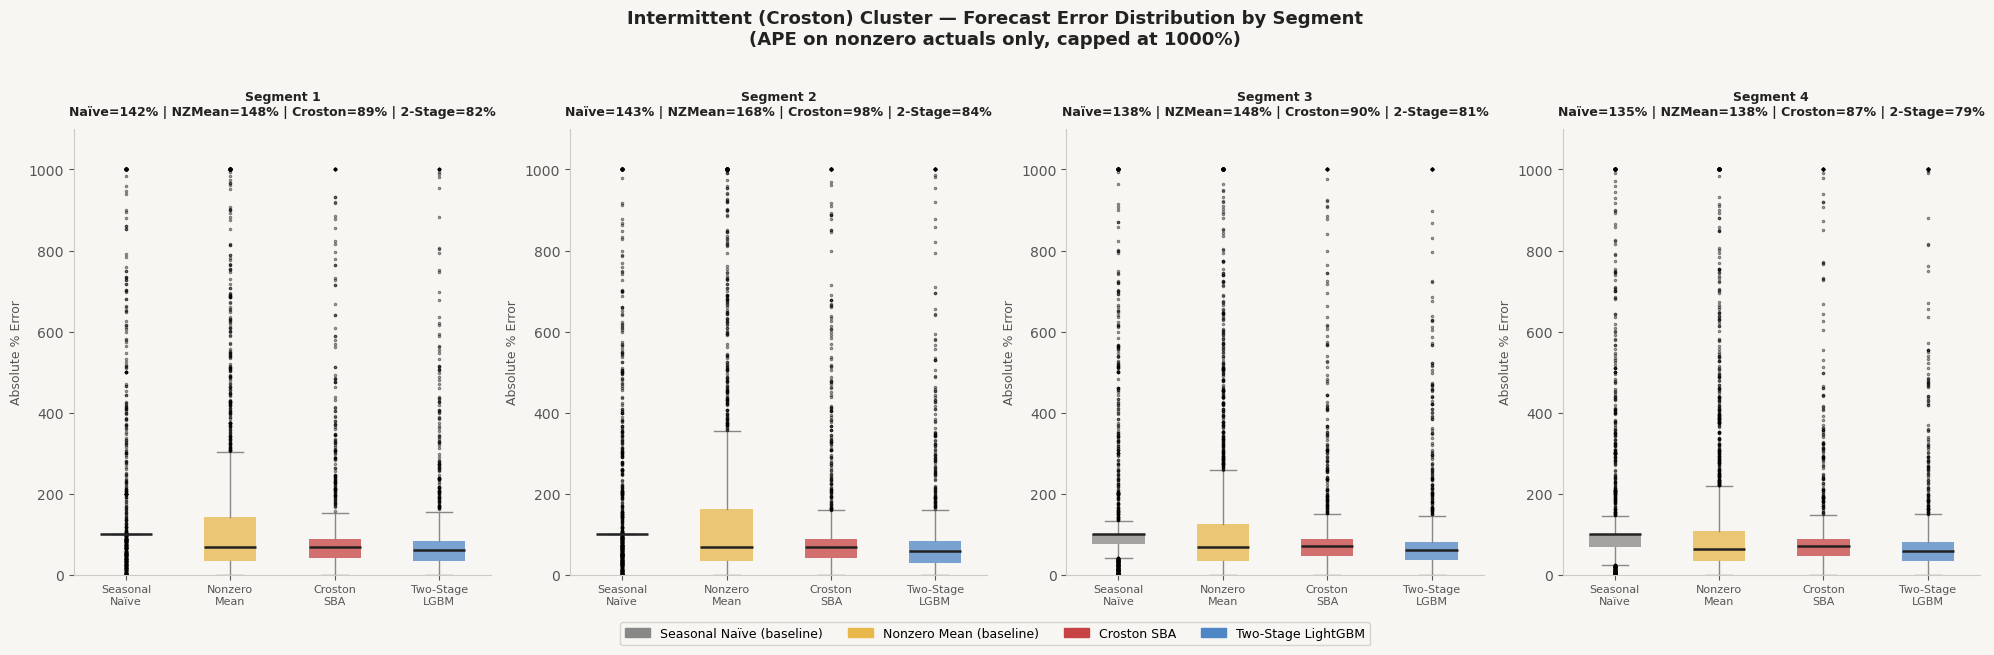

Saved: croston_cluster_forecasts.csv
Saved: twostage_stage1_croston.txt
Saved: twostage_stage2_croston.txt

── Croston Cluster — Final Summary ──────────────────────────────
  Products       : 1,711
  Test weeks     : 12
  % zero actuals : 60.6%
  APE cap        : 1000%

  Overall MAPE comparison:
    Seasonal Naïve   : 139.60%
    Nonzero Mean     : 150.42%
    Croston SBA      : 91.08%
    Two-Stage LGBM   : 81.56%

  Winner : Two-Stage LGBM  (MAPE = 81.56%)


In [16]:
!pip install lightgbm
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

Path("forecast figs").mkdir(exist_ok=True)

# ── 0. Config ─────────────────────────────────────────────────────────────────
CROSTON_CLUSTER_ID = -1
N_SEGMENTS         = 4          # 4 segments × 3 weeks = 12 test weeks
APE_CAP            = 1000.0     # cap individual APE at 1000% — standard for
                                 # intermittent demand to prevent extreme
                                 # observations dominating the aggregate metric
BG                 = "#F7F6F2"
PALETTE            = {
    "naive"    : "#888888",      # seasonal naïve baseline
    "nz_mean"  : "#E8B84B",      # nonzero mean baseline
    "croston"  : "#C74242",      # Croston SBA
    "twostage" : "#4F86C6",      # two-stage LightGBM
}

# ── 1. Pull panels ────────────────────────────────────────────────────────────
croston_train = panels[CROSTON_CLUSTER_ID]["train"]
croston_test  = panels[CROSTON_CLUSTER_ID]["test"]
feat_cols     = panels[CROSTON_CLUSTER_ID]["features"]

# Remove non-numeric columns that LightGBM cannot accept
# week_key is a string date column used for row matching — not a model feature
NON_NUMERIC    = {"week_key"}
feat_cols_lgb  = [c for c in feat_cols if c not in NON_NUMERIC]

print(f"Croston cluster train rows : {len(croston_train):,}")
print(f"Croston cluster test rows  : {len(croston_test):,}")
print(f"Croston cluster products   : {croston_train['StockCode'].nunique():,}")
print(f"Features (all)             : {len(feat_cols)}")
print(f"Features (LightGBM)        : {len(feat_cols_lgb)}")


# ── 2. MAPE utilities ─────────────────────────────────────────────────────────

def mape(actual, forecast, cap=APE_CAP):
    """
    MAPE on nonzero actuals only — standard for intermittent demand.
    Individual APE values are capped at `cap` percent to prevent
    extreme observations from dominating the aggregate metric.
    Returns value on 0-100 scale as required by assignment.
    """
    actual   = np.array(actual,   dtype=float)
    forecast = np.array(forecast, dtype=float)
    mask     = actual > 0
    if mask.sum() == 0:
        return np.nan
    ape = np.abs(actual[mask] - forecast[mask]) / actual[mask] * 100
    ape = np.clip(ape, 0, cap)
    return float(np.mean(ape))


def ape_series(actual, forecast, cap=APE_CAP):
    """
    Absolute percentage errors for nonzero actuals only.
    Capped at `cap` percent for box plot stability.
    """
    actual   = np.array(actual,   dtype=float)
    forecast = np.array(forecast, dtype=float)
    mask     = actual > 0
    if mask.sum() == 0:
        return np.array([])
    ape = np.abs(actual[mask] - forecast[mask]) / actual[mask] * 100
    return np.clip(ape, 0, cap)


# ── 3. Segment assignment ─────────────────────────────────────────────────────

def assign_segments(df, n_segments=N_SEGMENTS):
    """
    Divides 12 test weeks into n_segments equal chunks.
    Adds a 'segment' column (1-indexed).
    """
    unique_weeks = sorted(df["week"].unique())
    n_weeks      = len(unique_weeks)
    seg_size     = n_weeks // n_segments

    week_to_seg = {
        w: min(i // seg_size + 1, n_segments)
        for i, w in enumerate(unique_weeks)
    }

    df = df.copy()
    df["segment"] = df["week"].map(week_to_seg)

    print("\nTest week segments:")
    for seg in range(1, n_segments + 1):
        seg_weeks = [w for w, s in week_to_seg.items() if s == seg]
        print(f"  Segment {seg}: {min(seg_weeks)} → {max(seg_weeks)}  ({len(seg_weeks)} weeks)")

    return df


# ── 4. Baseline models ────────────────────────────────────────────────────────
#
# Baseline 1 — Seasonal Naïve (lag_52w)
#   Forecast = same week last year's actual sales.
#   Already computed in your panel as the lag_52w column.
#   Strong baseline for seasonal retail — all models must beat this.
#
# Baseline 2 — Nonzero Mean
#   Forecast = mean of nonzero training weeks per product.
#   More appropriate than global mean for intermittent demand.
#   Simpler than Croston — if Croston can't beat this, it adds no value.

def compute_baselines(train_panel, test_panel):
    """
    Computes both baseline forecasts for the Croston cluster.

    Returns
    -------
    pd.DataFrame : StockCode | week | week_start | actual |
                   forecast_naive | forecast_nz_mean
    """
    print("\nComputing baselines...")

    # ── Baseline 1: Seasonal Naïve ────────────────────────────────────────────
    result = (
        test_panel[["StockCode", "week", "week_start", "sales", "lag_52w"]]
        .copy()
        .rename(columns={"sales": "actual"})
    )
    result["forecast_naive"] = result["lag_52w"].fillna(0).clip(lower=0)

    # ── Baseline 2: Nonzero Mean per product ─────────────────────────────────
    def nonzero_mean(x):
        nz = x[x > 0]
        return float(nz.mean()) if len(nz) > 0 else 0.0

    nz_mean_df = (
        train_panel
        .groupby("StockCode")["sales"]
        .apply(nonzero_mean)
        .reset_index()
        .rename(columns={"sales": "forecast_nz_mean"})
    )

    result = result.merge(nz_mean_df, on="StockCode", how="left")
    result["forecast_nz_mean"] = result["forecast_nz_mean"].fillna(0).clip(lower=0)

    print(f"  Baseline rows    : {len(result):,}")
    pct_zero = (result["actual"] == 0).mean() * 100
    print(f"  % zero actuals   : {pct_zero:.1f}%")

    return result


baselines = compute_baselines(croston_train, croston_test)


# ── 5. SBA Croston — fit per product ──────────────────────────────────────────
#
# For each of the 1,711 products individually:
#   - Separately estimate average demand size when a sale occurs
#     and average interval between sales using exponential smoothing
#   - Combine into one flat weekly rate with SBA bias correction
#   - Apply that same flat rate to all 12 test weeks
#
# Forecast is capped at 3x the product's historical max to prevent
# exploding predictions from sparse training history.

def croston_sba(series, alpha=0.1):
    """
    Syntetos-Boylan Approximation (SBA) Croston variant.
    Fits on training history, returns flat weekly forecast rate.
    Capped at 3x historical max to prevent exploding sparse predictions.
    """
    demand = np.array(series, dtype=float)
    nz_idx = np.where(demand > 0)[0]

    if len(nz_idx) == 0:
        return 0.0
    if len(nz_idx) == 1:
        z_hat = demand[nz_idx[0]]
        p_hat = len(demand)
        rate  = (1 - alpha / 2) * z_hat / p_hat
        return min(rate, 3 * demand.max())

    z_hat = demand[nz_idx[0]]
    p_hat = nz_idx[0] + 1 if nz_idx[0] > 0 else 1

    for i in range(1, len(nz_idx)):
        idx      = nz_idx[i]
        prev_idx = nz_idx[i - 1]
        interval = idx - prev_idx
        z_hat    = alpha * demand[idx] + (1 - alpha) * z_hat
        p_hat    = alpha * interval    + (1 - alpha) * p_hat

    if p_hat == 0:
        return 0.0

    rate = (1 - alpha / 2) * z_hat / p_hat
    return min(rate, 3 * demand.max())


def fit_croston_forecasts(train_panel, test_panel):
    """
    Fits one SBA Croston model per product.
    Generates flat forecast rate for all 12 test weeks.

    Returns
    -------
    pd.DataFrame : StockCode | week | forecast_croston
    """
    results = []

    test_weeks_ordered = (
        test_panel[["week", "week_start"]]
        .drop_duplicates()
        .sort_values("week_start")
        ["week"]
        .tolist()
    )

    products = train_panel["StockCode"].unique()
    print(f"\nFitting SBA Croston for {len(products):,} products...")

    for stock_code in products:
        prod_train  = (
            train_panel[train_panel["StockCode"] == stock_code]
            .sort_values("week_start")
        )
        train_sales = prod_train["sales"].values
        flat_rate   = croston_sba(train_sales)

        prod_test = (
            test_panel[test_panel["StockCode"] == stock_code]
            .sort_values("week_start")
            .set_index("week")["sales"]
        )

        for week in test_weeks_ordered:
            results.append({
                "StockCode"        : stock_code,
                "week"             : week,
                "forecast_croston" : flat_rate,
            })

    return pd.DataFrame(results)


croston_preds = fit_croston_forecasts(croston_train, croston_test)


# ── 6. Two-stage LightGBM ─────────────────────────────────────────────────────
#
# Instead of one model trying to predict both zeros and nonzero demand,
# the two-stage model separates the problem into two questions:
#
# Stage 1 — Binary classifier:
#   "Will this product sell anything this week?"
#   Target: 1 if sales > 0, else 0
#   Trained on all rows. Output: P(demand > 0)
#
# Stage 2 — Regression:
#   "Given that something sells, how much?"
#   Trained ONLY on rows where sales > 0.
#   Output: expected quantity given demand occurs
#
# Final forecast = P(demand > 0) × predicted quantity
# This mirrors what Croston does conceptually but with the full
# power of all engineered features and cross-product learning.

print("\nTraining Two-Stage LightGBM on Croston cluster...")

X_train_all = croston_train[feat_cols_lgb]
y_train_all = croston_train["sales"]
X_test_all  = croston_test[feat_cols_lgb]

# Shared LightGBM parameters
lgb_base_params = {
    "n_estimators"     : 500,
    "learning_rate"    : 0.05,
    "num_leaves"       : 31,
    "min_child_samples": 20,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 0.1,
    "random_state"     : 42,
    "verbose"          : -1,
}

# ── Stage 1: Binary classifier — will demand occur? ───────────────────────────
print("  Stage 1: fitting binary classifier (demand occurrence)...")

y_train_binary = (y_train_all > 0).astype(int)
y_test_binary  = (croston_test["sales"] > 0).astype(int)

stage1_model = lgb.LGBMClassifier(
    **{**lgb_base_params, "objective": "binary", "metric": "binary_logloss"}
)
stage1_model.fit(
    X_train_all, y_train_binary,
    eval_set=[(X_test_all, y_test_binary)],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
    ],
)

prob_nonzero = stage1_model.predict_proba(X_test_all)[:, 1]
print(f"  Stage 1 done. Mean P(demand>0) on test: {prob_nonzero.mean():.3f}")

# ── Stage 2: Regression — how much given demand occurs? ──────────────────────
print("  Stage 2: fitting regression on nonzero demand rows only...")

nonzero_mask_train = y_train_all > 0
X_train_nz         = X_train_all[nonzero_mask_train]
y_train_nz         = y_train_all[nonzero_mask_train]

nonzero_mask_test  = croston_test["sales"] > 0
X_test_nz          = X_test_all[nonzero_mask_test]

print(f"  Stage 2 training on {len(X_train_nz):,} nonzero rows "
      f"({nonzero_mask_train.mean()*100:.1f}% of training data)")

stage2_model = lgb.LGBMRegressor(
    **{**lgb_base_params, "objective": "regression_l1", "metric": "mae"}
)
stage2_model.fit(
    X_train_nz, y_train_nz,
    eval_set=[(X_test_nz, croston_test["sales"][nonzero_mask_test])],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
    ],
)

# Final forecast = P(demand > 0) × predicted quantity
qty_pred_all   = np.clip(stage2_model.predict(X_test_all), 0, None)
twostage_preds = prob_nonzero * qty_pred_all

print(f"  Two-stage forecast done.")
print(f"  % zero predictions : {(twostage_preds == 0).mean()*100:.1f}%")

lgb_test_df = croston_test[["StockCode", "week", "sales"]].copy()
lgb_test_df = lgb_test_df.rename(columns={"sales": "actual"})
lgb_test_df["forecast_twostage"] = twostage_preds

print(f"  Two-stage forecast rows: {len(lgb_test_df):,}")


# ── 7. Merge all forecasts ────────────────────────────────────────────────────
combined = (
    baselines
    .merge(croston_preds,
           on=["StockCode", "week"], how="left")
    .merge(lgb_test_df[["StockCode", "week", "forecast_twostage"]],
           on=["StockCode", "week"], how="left")
)

combined = assign_segments(combined)
print(f"\nCombined forecast rows: {len(combined):,}")


# ── 8. Segmented MAPE table ───────────────────────────────────────────────────

def segmented_mape_table(df, n_segments=N_SEGMENTS):
    """
    MAPE per segment for all four methods.
    Individual APE values capped at APE_CAP before averaging.
    Baselines shown first so improvement over baseline is clear.
    """
    methods = {
        "Seasonal Naïve"  : "forecast_naive",
        "Nonzero Mean"    : "forecast_nz_mean",
        "Croston SBA"     : "forecast_croston",
        "Two-Stage LGBM"  : "forecast_twostage",
    }

    rows = []
    for seg in list(range(1, n_segments + 1)) + ["Overall"]:
        seg_df   = df if seg == "Overall" else df[df["segment"] == seg]
        n_total  = len(seg_df)
        n_zero   = (seg_df["actual"] == 0).sum()
        pct_zero = n_zero / n_total * 100 if n_total > 0 else np.nan

        row = {
            "Segment"        : "Overall" if seg == "Overall" else f"Segment {seg}",
            "Weeks"          : seg_df["week"].nunique(),
            "% Zero Actuals" : round(pct_zero, 1),
        }
        for name, col in methods.items():
            row[f"MAPE {name}"] = round(mape(seg_df["actual"], seg_df[col]), 2)

        rows.append(row)

    return pd.DataFrame(rows)


mape_table = segmented_mape_table(combined)
print("\nCroston Cluster — Segmented MAPE (all methods, APE capped at 1000%):")
print(mape_table.to_string(index=False))


# ── 9. Box plots ──────────────────────────────────────────────────────────────

def plot_croston_boxplots(df, mape_table, n_segments=N_SEGMENTS):
    """
    Box plots of APE per segment for all four methods.
    APE computed on nonzero actuals only, capped at APE_CAP.
    Saved to forecast figs/croston_boxplots.png
    """
    methods = {
        "Seasonal\nNaïve"  : ("forecast_naive",    PALETTE["naive"]),
        "Nonzero\nMean"    : ("forecast_nz_mean",  PALETTE["nz_mean"]),
        "Croston\nSBA"     : ("forecast_croston",  PALETTE["croston"]),
        "Two-Stage\nLGBM"  : ("forecast_twostage", PALETTE["twostage"]),
    }

    fig, axes = plt.subplots(1, n_segments, figsize=(5 * n_segments, 6), sharey=False)
    fig.patch.set_facecolor(BG)

    for seg_idx, seg in enumerate(range(1, n_segments + 1)):
        ax     = axes[seg_idx]
        seg_df = df[df["segment"] == seg]
        ax.set_facecolor(BG)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCBC5")
        ax.tick_params(colors="#555")

        ape_data   = []
        box_colors = []
        for label, (col, color) in methods.items():
            ape_data.append(ape_series(seg_df["actual"], seg_df[col]))
            box_colors.append(color)

        bp = ax.boxplot(
            ape_data,
            patch_artist=True,
            medianprops=dict(color="#222", lw=1.8),
            whiskerprops=dict(color="#888"),
            capprops=dict(color="#888"),
            flierprops=dict(marker=".", color="#aaa", ms=3, alpha=0.5),
            widths=0.5,
        )
        for patch, color in zip(bp["boxes"], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
            patch.set_edgecolor("none")

        seg_row = mape_table[mape_table["Segment"] == f"Segment {seg}"].iloc[0]

        ax.set_xticks(range(1, len(methods) + 1))
        ax.set_xticklabels(list(methods.keys()), fontsize=8, color="#555")
        ax.set_ylabel("Absolute % Error", fontsize=9, color="#555")
        ax.set_title(
            f"Segment {seg}\n"
            f"Naïve={seg_row['MAPE Seasonal Naïve']:.0f}% | "
            f"NZMean={seg_row['MAPE Nonzero Mean']:.0f}% | "
            f"Croston={seg_row['MAPE Croston SBA']:.0f}% | "
            f"2-Stage={seg_row['MAPE Two-Stage LGBM']:.0f}%",
            fontsize=9, pad=10, color="#222", fontweight="bold"
        )

        all_ape = np.concatenate([a for a in ape_data if len(a) > 0])
        if len(all_ape) > 0:
            cap = np.nanpercentile(all_ape, 99)
            ax.set_ylim(bottom=0, top=cap * 1.1)

    legend_patches = [
        mpatches.Patch(color=PALETTE["naive"],    label="Seasonal Naïve (baseline)"),
        mpatches.Patch(color=PALETTE["nz_mean"],  label="Nonzero Mean (baseline)"),
        mpatches.Patch(color=PALETTE["croston"],  label="Croston SBA"),
        mpatches.Patch(color=PALETTE["twostage"], label="Two-Stage LightGBM"),
    ]
    fig.legend(
        handles=legend_patches,
        loc="lower center",
        ncol=4,
        fontsize=9,
        frameon=True,
        facecolor=BG,
        edgecolor="#CCCBC5",
        bbox_to_anchor=(0.5, -0.05),
    )
    fig.suptitle(
        "Intermittent (Croston) Cluster — Forecast Error Distribution by Segment\n"
        f"(APE on nonzero actuals only, capped at {APE_CAP:.0f}%)",
        fontsize=13, y=1.02, color="#222", fontweight="bold"
    )
    fig.tight_layout()

    save_path = "forecast figs/croston_boxplots.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"\nSaved: {save_path}")
    plt.show()


plot_croston_boxplots(combined, mape_table)


# ── 10. Save outputs ──────────────────────────────────────────────────────────
combined.to_csv("clustering data/croston_cluster_forecasts.csv", index=False)
print("Saved: croston_cluster_forecasts.csv")

stage1_model.booster_.save_model("clustering data/twostage_stage1_croston.txt")
stage2_model.booster_.save_model("clustering data/twostage_stage2_croston.txt")
print("Saved: twostage_stage1_croston.txt")
print("Saved: twostage_stage2_croston.txt")


# ── 11. Final summary ─────────────────────────────────────────────────────────
print("\n── Croston Cluster — Final Summary ──────────────────────────────")
print(f"  Products       : {combined['StockCode'].nunique():,}")
print(f"  Test weeks     : {combined['week'].nunique()}")
pct_zero = (combined["actual"] == 0).mean() * 100
print(f"  % zero actuals : {pct_zero:.1f}%")
print(f"  APE cap        : {APE_CAP:.0f}%")

overall = mape_table[mape_table["Segment"] == "Overall"].iloc[0]
print("\n  Overall MAPE comparison:")
print(f"    Seasonal Naïve   : {overall['MAPE Seasonal Naïve']:.2f}%")
print(f"    Nonzero Mean     : {overall['MAPE Nonzero Mean']:.2f}%")
print(f"    Croston SBA      : {overall['MAPE Croston SBA']:.2f}%")
print(f"    Two-Stage LGBM   : {overall['MAPE Two-Stage LGBM']:.2f}%")

scores = {
    "Seasonal Naïve"  : overall["MAPE Seasonal Naïve"],
    "Nonzero Mean"    : overall["MAPE Nonzero Mean"],
    "Croston SBA"     : overall["MAPE Croston SBA"],
    "Two-Stage LGBM"  : overall["MAPE Two-Stage LGBM"],
}
winner = min(scores, key=scores.get)
print(f"\n  Winner : {winner}  (MAPE = {scores[winner]:.2f}%)")

## Cluster 1.0: Steady regulars

C1 train rows  : 54,348
C1 test rows   : 15,528
C1 products    : 1,294
Features       : 36
% zero actuals : 22.4%

Computing baselines...
  Baseline rows    : 15,528
  % zero actuals   : 22.4%

Training plain LightGBM on C1 (Steady regulars)...
[100]	valid_0's l1: 55.2579
[200]	valid_0's l1: 55.004
[300]	valid_0's l1: 54.9342
LightGBM forecast rows: 15,528

Test week segments:
  Segment 1: 2011-09-19/2011-09-25 → 2011-10-03/2011-10-09  (3 weeks)
  Segment 2: 2011-10-10/2011-10-16 → 2011-10-24/2011-10-30  (3 weeks)
  Segment 3: 2011-10-31/2011-11-06 → 2011-11-14/2011-11-20  (3 weeks)
  Segment 4: 2011-11-21/2011-11-27 → 2011-12-05/2011-12-11  (3 weeks)

Combined forecast rows: 15,528

C1 (Steady Regulars) — Segmented MAPE (APE capped at 1000%):
  Segment  Weeks  % Zero Actuals  MAPE Seasonal Naïve  MAPE Historical Mean  MAPE LightGBM
Segment 1      3            22.7               204.48                127.16          91.05
Segment 2      3            23.2               194.65           

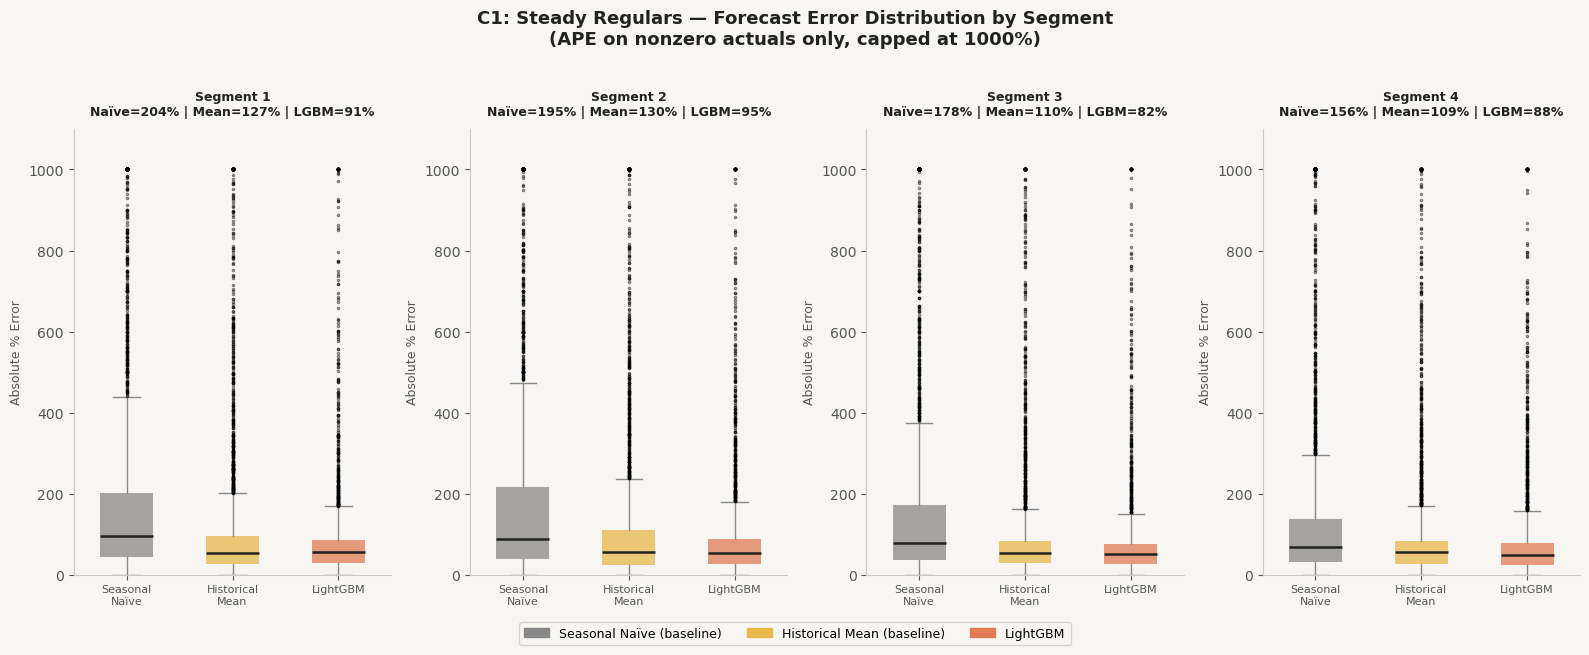

Saved: c1_forecasts.csv
Saved: lgbm_c1.txt

── C1: Steady Regulars — Final Summary ──────────────────────────
  Products       : 1,294
  Test weeks     : 12
  % zero actuals : 22.4%
  APE cap        : 1000%

  Overall MAPE comparison:
    Seasonal Naïve   : 183.15%
    Historical Mean  : 118.86%
    LightGBM         : 88.92%

  Winner : LightGBM  (MAPE = 88.92%)


In [17]:
!pip install lightgbm
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

Path("forecast figs").mkdir(exist_ok=True)

# ── 0. Config ─────────────────────────────────────────────────────────────────
C1_CLUSTER_ID = 1
N_SEGMENTS    = 4
APE_CAP       = 1000.0
BG            = "#F7F6F2"
PALETTE       = {
    "naive" : "#888888",
    "mean"  : "#E8B84B",
    "lgbm"  : "#E07B54",
}

# ── 1. Pull panels ────────────────────────────────────────────────────────────
c1_train  = panels[C1_CLUSTER_ID]["train"]
c1_test   = panels[C1_CLUSTER_ID]["test"]
feat_cols  = panels[C1_CLUSTER_ID]["features"]

NON_NUMERIC   = {"week_key"}
feat_cols_lgb = [c for c in feat_cols if c not in NON_NUMERIC]

print(f"C1 train rows  : {len(c1_train):,}")
print(f"C1 test rows   : {len(c1_test):,}")
print(f"C1 products    : {c1_train['StockCode'].nunique():,}")
print(f"Features       : {len(feat_cols_lgb)}")
pct_zero = (c1_test["sales"] == 0).mean() * 100
print(f"% zero actuals : {pct_zero:.1f}%")


# ── 2. MAPE utilities ─────────────────────────────────────────────────────────

def mape(actual, forecast, cap=APE_CAP):
    """
    MAPE on nonzero actuals only.
    Individual APE values capped at `cap` percent.
    Returns value on 0-100 scale as required by assignment.
    """
    actual   = np.array(actual,   dtype=float)
    forecast = np.array(forecast, dtype=float)
    mask     = actual > 0
    if mask.sum() == 0:
        return np.nan
    ape = np.abs(actual[mask] - forecast[mask]) / actual[mask] * 100
    ape = np.clip(ape, 0, cap)
    return float(np.mean(ape))


def ape_series(actual, forecast, cap=APE_CAP):
    """
    Absolute percentage errors for nonzero actuals only.
    Capped at `cap` percent for box plot stability.
    """
    actual   = np.array(actual,   dtype=float)
    forecast = np.array(forecast, dtype=float)
    mask     = actual > 0
    if mask.sum() == 0:
        return np.array([])
    ape = np.abs(actual[mask] - forecast[mask]) / actual[mask] * 100
    return np.clip(ape, 0, cap)


# ── 3. Segment assignment ─────────────────────────────────────────────────────

def assign_segments(df, n_segments=N_SEGMENTS):
    """
    Divides 12 test weeks into n_segments equal chunks.
    Adds a 'segment' column (1-indexed).
    """
    unique_weeks = sorted(df["week"].unique())
    n_weeks      = len(unique_weeks)
    seg_size     = n_weeks // n_segments

    week_to_seg = {
        w: min(i // seg_size + 1, n_segments)
        for i, w in enumerate(unique_weeks)
    }

    df = df.copy()
    df["segment"] = df["week"].map(week_to_seg)

    print("\nTest week segments:")
    for seg in range(1, n_segments + 1):
        seg_weeks = [w for w, s in week_to_seg.items() if s == seg]
        print(f"  Segment {seg}: {min(seg_weeks)} → {max(seg_weeks)}  ({len(seg_weeks)} weeks)")

    return df


# ── 4. Baselines ──────────────────────────────────────────────────────────────
#
# Baseline 1 — Seasonal Naïve (lag_52w)
#   Same week last year. Very strong for steady regular products
#   with clear year-over-year patterns. Already in panel as lag_52w.
#
# Baseline 2 — Historical Mean
#   Mean of all training weeks per product including zeros.
#   Simple flat forecast — models must beat this to add value.

def compute_baselines(train_panel, test_panel):
    """
    Computes both baselines for C1.

    Returns
    -------
    pd.DataFrame : StockCode | week | week_start | actual |
                   forecast_naive | forecast_mean
    """
    print("\nComputing baselines...")

    # ── Baseline 1: Seasonal Naïve ────────────────────────────────────────────
    result = (
        test_panel[["StockCode", "week", "week_start", "sales", "lag_52w"]]
        .copy()
        .rename(columns={"sales": "actual"})
    )
    result["forecast_naive"] = result["lag_52w"].fillna(0).clip(lower=0)

    # ── Baseline 2: Historical Mean ───────────────────────────────────────────
    hist_mean_df = (
        train_panel
        .groupby("StockCode")["sales"]
        .mean()
        .reset_index()
        .rename(columns={"sales": "forecast_mean"})
    )

    result = result.merge(hist_mean_df, on="StockCode", how="left")
    result["forecast_mean"] = result["forecast_mean"].fillna(0).clip(lower=0)

    print(f"  Baseline rows    : {len(result):,}")
    pct_zero = (result["actual"] == 0).mean() * 100
    print(f"  % zero actuals   : {pct_zero:.1f}%")

    return result


baselines = compute_baselines(c1_train, c1_test)


# ── 5. Plain LightGBM ────────────────────────────────────────────────────────
#
# One global model trained on all 1,294 C1 products simultaneously.
# Plain regression is appropriate here — C1 products sell consistently
# so there is no need for a two-stage classifier. The model learns
# shared patterns across all steady products using lag features,
# calendar signals, and product characteristics as inputs.
#
# Key features for this cluster:
#   lag_52w          — same week last year, strong anchor for steady products
#   weeks_to_christmas — captures the pre-Christmas ramp up
#   roll_mean_4w     — recent 4-week average, captures current demand level
#   product features — cv, q4_pct etc. help model adapt per product type

print("\nTraining plain LightGBM on C1 (Steady regulars)...")

X_train = c1_train[feat_cols_lgb]
y_train = c1_train["sales"]
X_test  = c1_test[feat_cols_lgb]

lgb_params = {
    "objective"        : "regression_l1",  # MAE loss — robust to outliers
    "metric"           : "mae",
    "n_estimators"     : 500,
    "learning_rate"    : 0.05,
    "num_leaves"       : 31,
    "min_child_samples": 20,
    "subsample"        : 0.8,
    "colsample_bytree" : 0.8,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 0.1,
    "random_state"     : 42,
    "verbose"          : -1,
}

lgb_model = lgb.LGBMRegressor(**lgb_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, c1_test["sales"])],
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100),
    ],
)

lgb_preds = np.clip(lgb_model.predict(X_test), 0, None)

lgb_test_df = c1_test[["StockCode", "week", "sales"]].copy()
lgb_test_df = lgb_test_df.rename(columns={"sales": "actual"})
lgb_test_df["forecast_lgbm"] = lgb_preds

print(f"LightGBM forecast rows: {len(lgb_test_df):,}")


# ── 6. Merge all forecasts ────────────────────────────────────────────────────
combined = (
    baselines
    .merge(lgb_test_df[["StockCode", "week", "forecast_lgbm"]],
           on=["StockCode", "week"], how="left")
)

combined = assign_segments(combined)
print(f"\nCombined forecast rows: {len(combined):,}")


# ── 7. Segmented MAPE table ───────────────────────────────────────────────────

def segmented_mape_table(df, n_segments=N_SEGMENTS):
    """
    MAPE per segment for all three methods.
    APE capped at APE_CAP before averaging.
    Baselines shown first so improvement is clear.
    """
    methods = {
        "Seasonal Naïve"  : "forecast_naive",
        "Historical Mean" : "forecast_mean",
        "LightGBM"        : "forecast_lgbm",
    }

    rows = []
    for seg in list(range(1, n_segments + 1)) + ["Overall"]:
        seg_df   = df if seg == "Overall" else df[df["segment"] == seg]
        n_total  = len(seg_df)
        n_zero   = (seg_df["actual"] == 0).sum()
        pct_zero = n_zero / n_total * 100 if n_total > 0 else np.nan

        row = {
            "Segment"        : "Overall" if seg == "Overall" else f"Segment {seg}",
            "Weeks"          : seg_df["week"].nunique(),
            "% Zero Actuals" : round(pct_zero, 1),
        }
        for name, col in methods.items():
            row[f"MAPE {name}"] = round(mape(seg_df["actual"], seg_df[col]), 2)

        rows.append(row)

    return pd.DataFrame(rows)


mape_table = segmented_mape_table(combined)
print("\nC1 (Steady Regulars) — Segmented MAPE (APE capped at 1000%):")
print(mape_table.to_string(index=False))


# ── 8. Box plots ──────────────────────────────────────────────────────────────

def plot_c1_boxplots(df, mape_table, n_segments=N_SEGMENTS):
    """
    Box plots of APE per segment for all three methods.
    Saved to forecast figs/c1_boxplots.png
    """
    methods = {
        "Seasonal\nNaïve"  : ("forecast_naive", PALETTE["naive"]),
        "Historical\nMean" : ("forecast_mean",  PALETTE["mean"]),
        "LightGBM"         : ("forecast_lgbm",  PALETTE["lgbm"]),
    }

    fig, axes = plt.subplots(1, n_segments, figsize=(4 * n_segments, 6), sharey=False)
    fig.patch.set_facecolor(BG)

    for seg_idx, seg in enumerate(range(1, n_segments + 1)):
        ax     = axes[seg_idx]
        seg_df = df[df["segment"] == seg]
        ax.set_facecolor(BG)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#CCCBC5")
        ax.tick_params(colors="#555")

        ape_data   = []
        box_colors = []
        for label, (col, color) in methods.items():
            ape_data.append(ape_series(seg_df["actual"], seg_df[col]))
            box_colors.append(color)

        bp = ax.boxplot(
            ape_data,
            patch_artist=True,
            medianprops=dict(color="#222", lw=1.8),
            whiskerprops=dict(color="#888"),
            capprops=dict(color="#888"),
            flierprops=dict(marker=".", color="#aaa", ms=3, alpha=0.5),
            widths=0.5,
        )
        for patch, color in zip(bp["boxes"], box_colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.75)
            patch.set_edgecolor("none")

        seg_row = mape_table[mape_table["Segment"] == f"Segment {seg}"].iloc[0]

        ax.set_xticks(range(1, len(methods) + 1))
        ax.set_xticklabels(list(methods.keys()), fontsize=8, color="#555")
        ax.set_ylabel("Absolute % Error", fontsize=9, color="#555")
        ax.set_title(
            f"Segment {seg}\n"
            f"Naïve={seg_row['MAPE Seasonal Naïve']:.0f}% | "
            f"Mean={seg_row['MAPE Historical Mean']:.0f}% | "
            f"LGBM={seg_row['MAPE LightGBM']:.0f}%",
            fontsize=9, pad=10, color="#222", fontweight="bold"
        )

        all_ape = np.concatenate([a for a in ape_data if len(a) > 0])
        if len(all_ape) > 0:
            cap = np.nanpercentile(all_ape, 99)
            ax.set_ylim(bottom=0, top=cap * 1.1)

    legend_patches = [
        mpatches.Patch(color=PALETTE["naive"], label="Seasonal Naïve (baseline)"),
        mpatches.Patch(color=PALETTE["mean"],  label="Historical Mean (baseline)"),
        mpatches.Patch(color=PALETTE["lgbm"],  label="LightGBM"),
    ]
    fig.legend(
        handles=legend_patches,
        loc="lower center",
        ncol=3,
        fontsize=9,
        frameon=True,
        facecolor=BG,
        edgecolor="#CCCBC5",
        bbox_to_anchor=(0.5, -0.05),
    )
    fig.suptitle(
        "C1: Steady Regulars — Forecast Error Distribution by Segment\n"
        f"(APE on nonzero actuals only, capped at {APE_CAP:.0f}%)",
        fontsize=13, y=1.02, color="#222", fontweight="bold"
    )
    fig.tight_layout()

    save_path = "forecast figs/c1_boxplots.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    print(f"\nSaved: {save_path}")
    plt.show()


plot_c1_boxplots(combined, mape_table)


# ── 9. Save outputs ───────────────────────────────────────────────────────────
combined.to_csv("clustering data/c1_forecasts.csv", index=False)
print("Saved: c1_forecasts.csv")

lgb_model.booster_.save_model("clustering data/lgbm_c1.txt")
print("Saved: lgbm_c1.txt")


# ── 10. Final summary ─────────────────────────────────────────────────────────
print("\n── C1: Steady Regulars — Final Summary ──────────────────────────")
print(f"  Products       : {combined['StockCode'].nunique():,}")
print(f"  Test weeks     : {combined['week'].nunique()}")
pct_zero = (combined["actual"] == 0).mean() * 100
print(f"  % zero actuals : {pct_zero:.1f}%")
print(f"  APE cap        : {APE_CAP:.0f}%")

overall = mape_table[mape_table["Segment"] == "Overall"].iloc[0]
print("\n  Overall MAPE comparison:")
print(f"    Seasonal Naïve   : {overall['MAPE Seasonal Naïve']:.2f}%")
print(f"    Historical Mean  : {overall['MAPE Historical Mean']:.2f}%")
print(f"    LightGBM         : {overall['MAPE LightGBM']:.2f}%")

scores = {
    "Seasonal Naïve"  : overall["MAPE Seasonal Naïve"],
    "Historical Mean" : overall["MAPE Historical Mean"],
    "LightGBM"        : overall["MAPE LightGBM"],
}
winner = min(scores, key=scores.get)
print(f"\n  Winner : {winner}  (MAPE = {scores[winner]:.2f}%)")